<h1><b>WALMART CASE STUDY: Confidence Interval and Central Limit Theorem (CLT)</b></h1>

<h2>BY: Atharva Nitin Deshpande</h2>

Data Science and Machine Learning Program 2024, Scaler Academy, India

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('walmart_data.csv')

In [3]:
df.sample(10)

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
390734,1000119,P00000842,F,0-17,10,C,1,0,2,9982
232555,1005852,P00265242,F,26-35,1,A,0,1,5,8726
524674,1002872,P00135742,M,26-35,20,B,1,0,6,16635
290915,1002872,P00001642,M,26-35,20,B,1,0,8,6035
210674,1002486,P00294842,M,18-25,12,A,1,0,8,7774
186515,1004778,P00204742,M,26-35,0,C,1,1,8,9794
475331,1001228,P00210642,M,26-35,1,C,4+,1,8,8096
207383,1001950,P00000142,M,26-35,12,C,1,0,3,13253
157697,1000352,P00346042,M,18-25,4,A,0,0,6,16199
363482,1001926,P00253142,F,0-17,0,B,1,0,1,15627


In [4]:
df.shape

(550068, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   User_ID                     550068 non-null  int64 
 1   Product_ID                  550068 non-null  object
 2   Gender                      550068 non-null  object
 3   Age                         550068 non-null  object
 4   Occupation                  550068 non-null  int64 
 5   City_Category               550068 non-null  object
 6   Stay_In_Current_City_Years  550068 non-null  object
 7   Marital_Status              550068 non-null  int64 
 8   Product_Category            550068 non-null  int64 
 9   Purchase                    550068 non-null  int64 
dtypes: int64(5), object(5)
memory usage: 42.0+ MB


In [6]:
df.isna().sum()

User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category              0
Purchase                      0
dtype: int64

In [7]:
df[df.duplicated()].shape

(0, 10)

<Axes: xlabel='Purchase', ylabel='Density'>

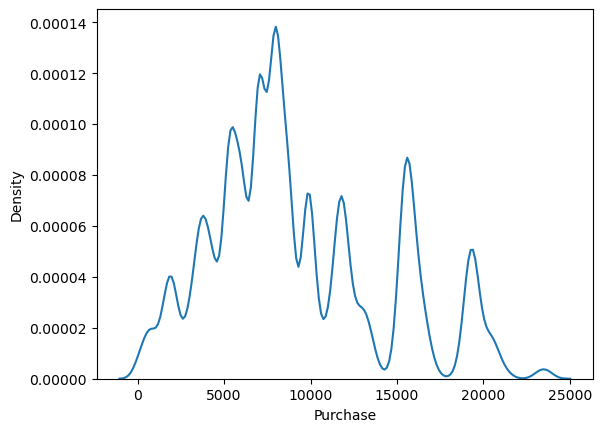

In [8]:
sns.kdeplot(data=df, x='Purchase')

In [9]:
df.nunique()

User_ID                        5891
Product_ID                     3631
Gender                            2
Age                               7
Occupation                       21
City_Category                     3
Stay_In_Current_City_Years        5
Marital_Status                    2
Product_Category                 20
Purchase                      18105
dtype: int64

<Axes: ylabel='Purchase'>

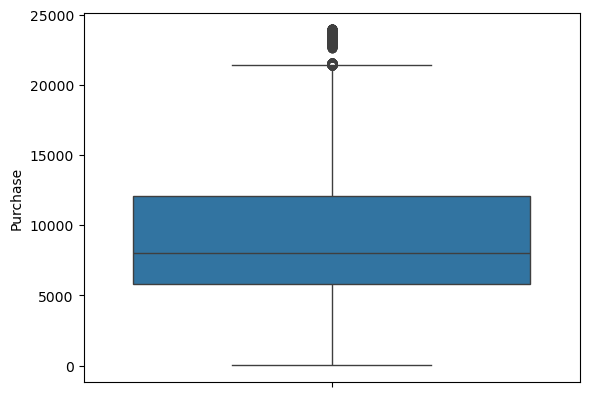

In [10]:
sns.boxplot(data=df, y='Purchase')

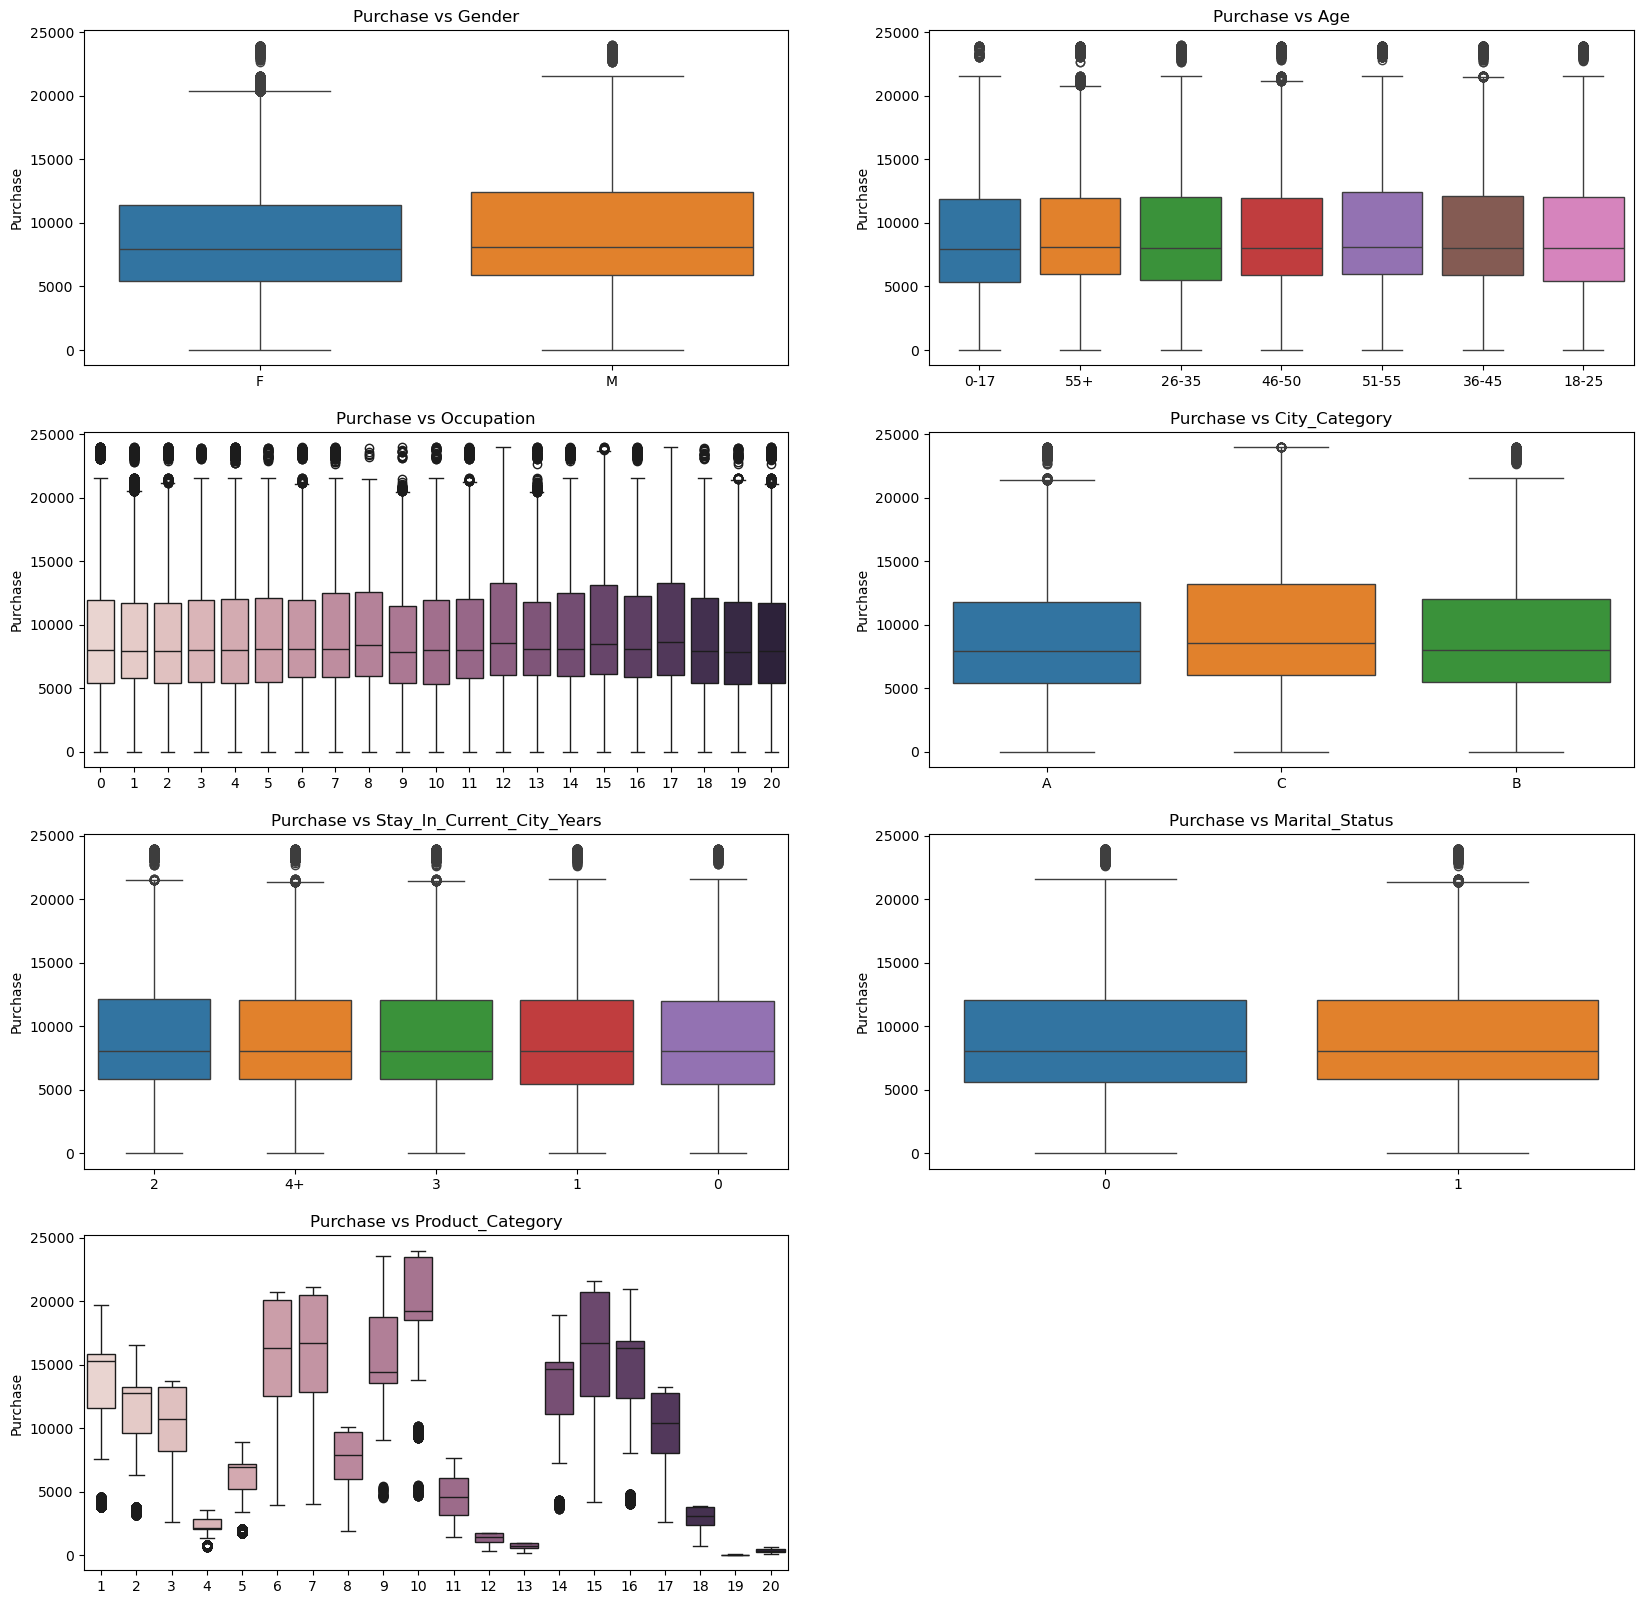

In [11]:
cols = ['Gender','Age','Occupation','City_Category','Stay_In_Current_City_Years','Marital_Status','Product_Category']

plt.figure(figsize=(20,20))
for i in range(7):
    plt.subplot(4,2,i+1)
    sns.boxplot(data=df, y='Purchase', x=df[cols[i]], hue=df[cols[i]], legend=False)
    plt.title(f'Purchase vs {cols[i]}')
    plt.xlabel('')

In [12]:
Q1 = df['Purchase'].quantile(0.25) # 25th percentile
Q3 = df['Purchase'].quantile(0.75) # 75th percentile
print(f'Q1 = {Q1}\nQ3 = {Q3}')

IQR = Q3-Q1
lower_bound = Q1-1.5*IQR
upper_bound = Q3+1.5*IQR
outliers = df[(df['Purchase'] < lower_bound) | (df['Purchase'] > upper_bound)]

print('Number of outliers = ',len(outliers))
print('Percentage of outliers =', round(len(outliers)/len(df)*100,2),'%')

Q1 = 5823.0
Q3 = 12054.0
Number of outliers =  2677
Percentage of outliers = 0.49 %


In [13]:
df.drop(outliers.index, inplace=True)
df.reset_index(drop=True, inplace=True)

<Axes: ylabel='Purchase'>

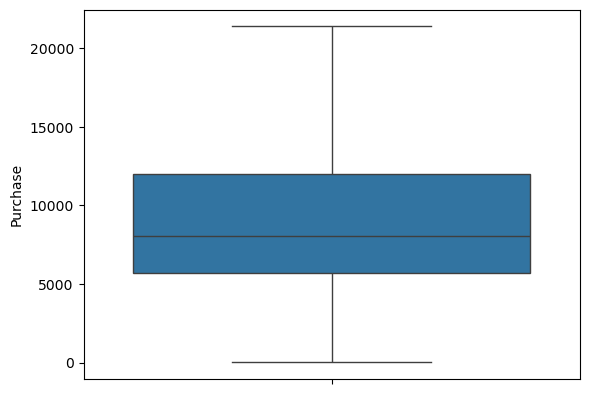

In [14]:
sns.boxplot(data=df, y='Purchase')

In [15]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
User_ID,547391.0,NaN,NaN,NaN,1003028.432583,1727.356809,1000001.0,1001516.0,1003075.0,1004478.0,1006040.0
Product_ID,547391,3631,P00265242,1880,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,547391,2,M,412171,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,547391,7,26-35,218661,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Occupation,547391.0,NaN,NaN,NaN,8.074627,6.521586,0.0,2.0,7.0,14.0,20.0
City_Category,547391,3,B,230114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Stay_In_Current_City_Years,547391,5,1,192845,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital_Status,547391.0,NaN,NaN,NaN,0.409486,0.491739,0.0,0.0,0.0,1.0,1.0
Product_Category,547391.0,NaN,NaN,NaN,5.378945,3.927383,1.0,1.0,5.0,8.0,20.0
Purchase,547391.0,NaN,NaN,NaN,9195.627195,4938.872953,12.0,5721.0,8038.0,12019.0,21399.0


In [16]:
for column in df:
    print(column)
    print("Dtype:",df[column].dtype)
    print(df[column].unique())
    print('\n')

User_ID
Dtype: int64
[1000001 1000002 1000003 ... 1004113 1005391 1001529]


Product_ID
Dtype: object
['P00069042' 'P00248942' 'P00087842' ... 'P00370293' 'P00371644'
 'P00370853']


Gender
Dtype: object
['F' 'M']


Age
Dtype: object
['0-17' '55+' '26-35' '46-50' '51-55' '36-45' '18-25']


Occupation
Dtype: int64
[10 16 15  7 20  9  1 12 17  0  3  4 11  8 19  2 18  5 14 13  6]


City_Category
Dtype: object
['A' 'C' 'B']


Stay_In_Current_City_Years
Dtype: object
['2' '4+' '3' '1' '0']


Marital_Status
Dtype: int64
[0 1]


Product_Category
Dtype: int64
[ 3  1 12  8  5  4  2  6 14 11 13 15  7 16 18 10 17  9 20 19]


Purchase
Dtype: int64
[ 8370 15200  1422 ...   135   123   613]




In [17]:
cat_cols = ['User_ID','Product_ID','Gender','Occupation','City_Category','Marital_Status','Product_Category']

for col in cat_cols:
    df[col] = df[col].astype('category')

In [18]:
df['Age'] = pd.Categorical(df['Age'], categories=['0-17','18-25','26-35','36-45','46-50','51-55','55+'],ordered=True)

In [19]:
df['Stay_In_Current_City_Years'] = pd.Categorical(df['Stay_In_Current_City_Years'], categories=['0','1','2','3','4+'], ordered=True)

In [20]:
round(df.groupby('Gender',observed=True)['User_ID'].nunique()/df.groupby('Gender',observed=True)['User_ID'].nunique().sum()*100,1)

Gender
F    28.3
M    71.7
Name: User_ID, dtype: float64

In [21]:
cols = ['User_ID','Gender','Age','Occupation','City_Category','Stay_In_Current_City_Years','Marital_Status','Product_Category']

cat_wise_unique_User_ID_Counts = df[cols].melt(id_vars='User_ID',value_vars=cols[1:]).groupby(['variable','value'])[['User_ID']].nunique()
cat_wise_unique_User_ID_Counts

User_ID
variable                   value         
Age                        0-17       218
                           18-25     1069
                           26-35     2053
                           36-45     1167
                           46-50      531
                           51-55      481
                           55+        372
City_Category              A         1045
                           B         1707
                           C         3139
Gender                     F         1666
                           M         4225
Marital_Status             0         3417
                           1         2474
Occupation                 0          688
                           1          517
                           2          256
                           3          170
                           4          740
                           5          111
                           6          228
                           7          669
                           8           17
                           9           88
                           10         192
                           11         128
                           12         376
                           13         140
                           14         294
                           15         140
                           16         235
                           17         491
                           18          67
                           19          71
                           20         273
Product_Category           1         5767
                           2         4296
                           3         3838
                           4         3361
                           5         5751
                           6         4085
                           7         1461
                           8         5659
                           9          335
                           10        1655
                           11        3583
                           12        1567
                           13        2272
                           14         971
                           15        2377
                           16        3130
                           17         426
                           18        1284
                           19        1603
                           20        2550
Stay_In_Current_City_Years 0          772
                           1         2086
                           2         1145
                           3          979
                           4+         909

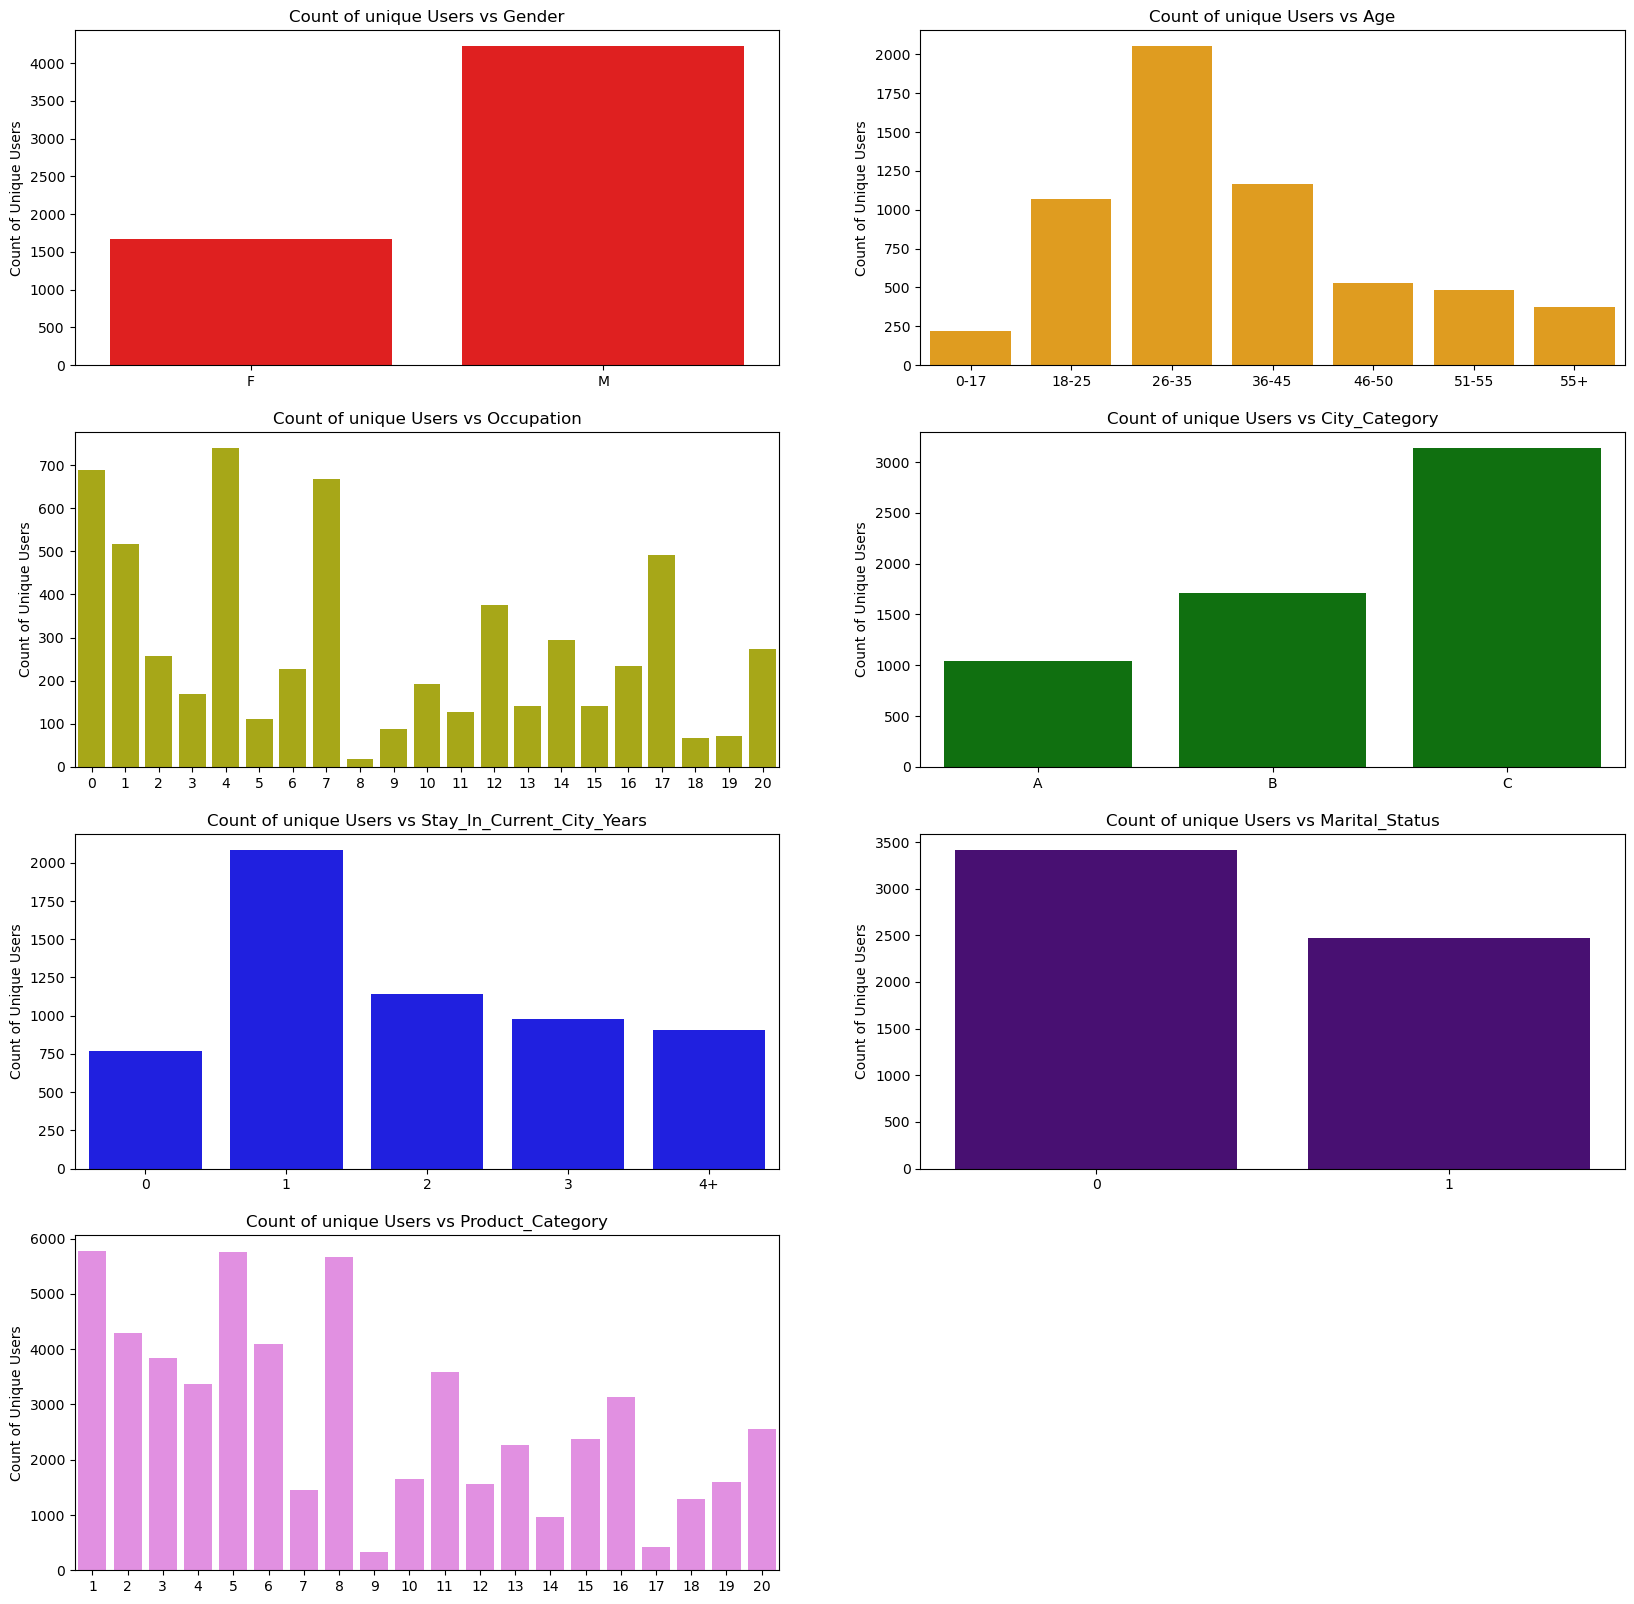

In [22]:
plt.figure(figsize=(20,20))
colors = ['r','orange','y','g','b','indigo','violet']
for i in range(7):
    plt.subplot(4,2,i+1)
    plt.title(f'Count of unique Users vs {cols[i+1]}')
    sns.barplot(cat_wise_unique_User_ID_Counts.loc[(cols[i+1]),'User_ID'], color=colors[i])
    plt.xlabel('')
    plt.ylabel('Count of Unique Users')

In [23]:
gender_wise_unique_User_ID_Counts = df[cols].melt(
    id_vars=['User_ID','Gender'],
    value_vars=cols[2:]
).groupby(['variable','value','Gender'], observed=True)[['User_ID']].nunique()

gender_wise_unique_User_ID_Counts


User_ID
variable                   value Gender         
Age                        0-17  F            78
                                 M           140
                           18-25 F           287
                                 M           782
                           26-35 F           545
...                                          ...
Stay_In_Current_City_Years 2     M           817
                           3     F           286
                                 M           693
                           4+    F           234
                                 M           675

[116 rows x 1 columns]

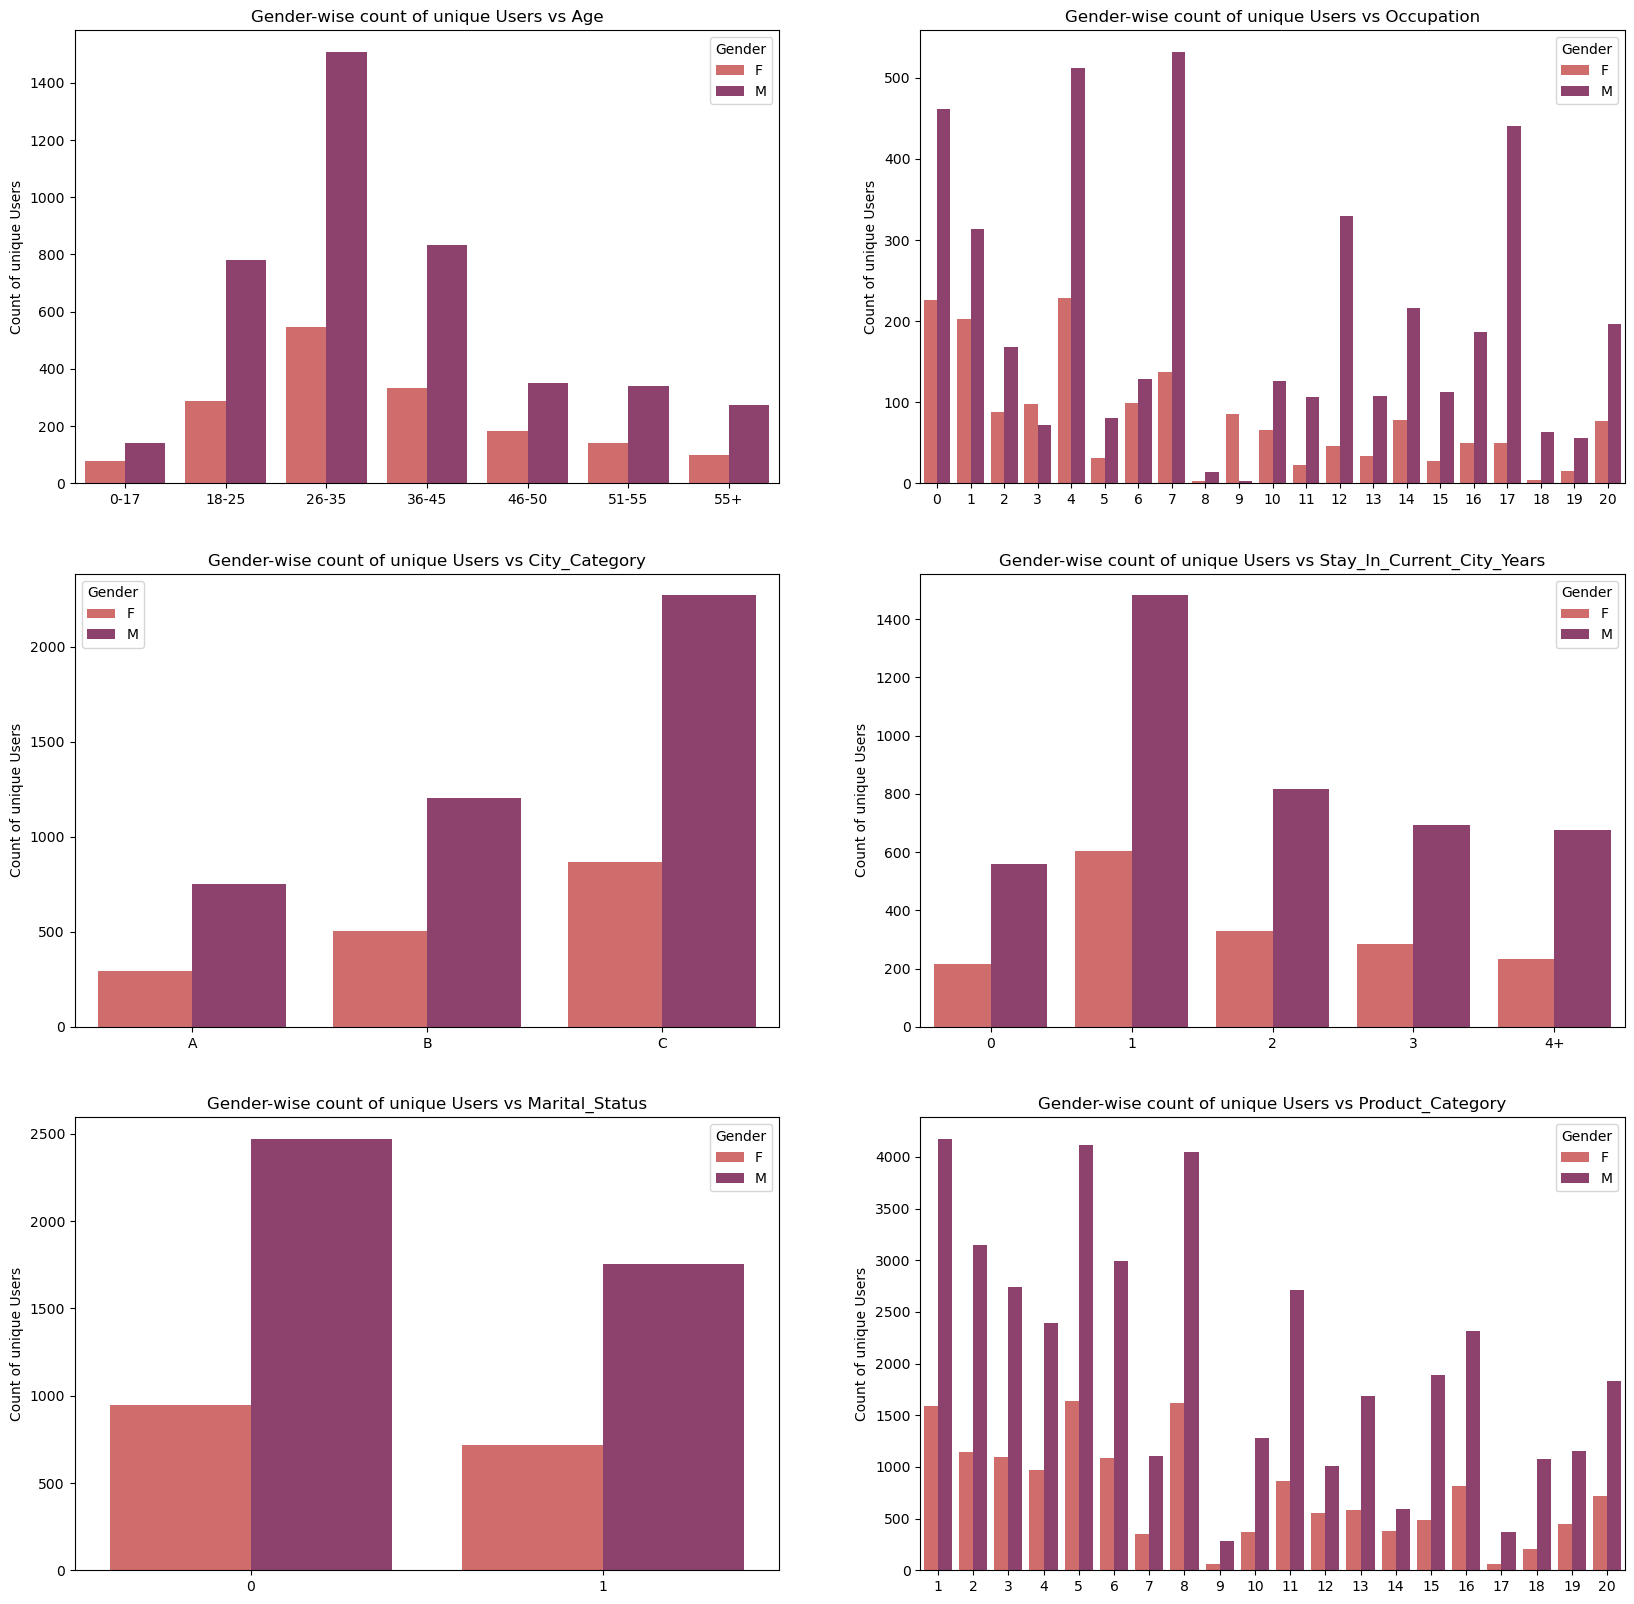

In [73]:
plt.figure(figsize=(20,20))
for i in range(6):
    plt.subplot(3,2,i+1)
    plt.title(f'Gender-wise count of unique Users vs {cols[i+2]}')
    sns.barplot(data=gender_wise_unique_User_ID_Counts.loc[(cols[i+2])], y='User_ID', x='value', hue='Gender', palette='flare')
    plt.xlabel('')
    plt.ylabel('Count of unique Users')

In [25]:
marital_status_wise_unique_User_ID_Counts = df[cols].melt(
    id_vars=['User_ID','Marital_Status'],
    value_vars=cols[:6]+cols[7:]
).groupby(['variable','value','Marital_Status'], observed=True)[['User_ID']].nunique()

marital_status_wise_unique_User_ID_Counts


User_ID
variable                   value Marital_Status         
Age                        0-17  0                   218
                           18-25 0                   825
                                 1                   244
                           26-35 0                  1244
                                 1                   809
...                                                  ...
Stay_In_Current_City_Years 2     1                   482
                           3     0                   579
                                 1                   400
                           4+    0                   540
                                 1                   369

[115 rows x 1 columns]

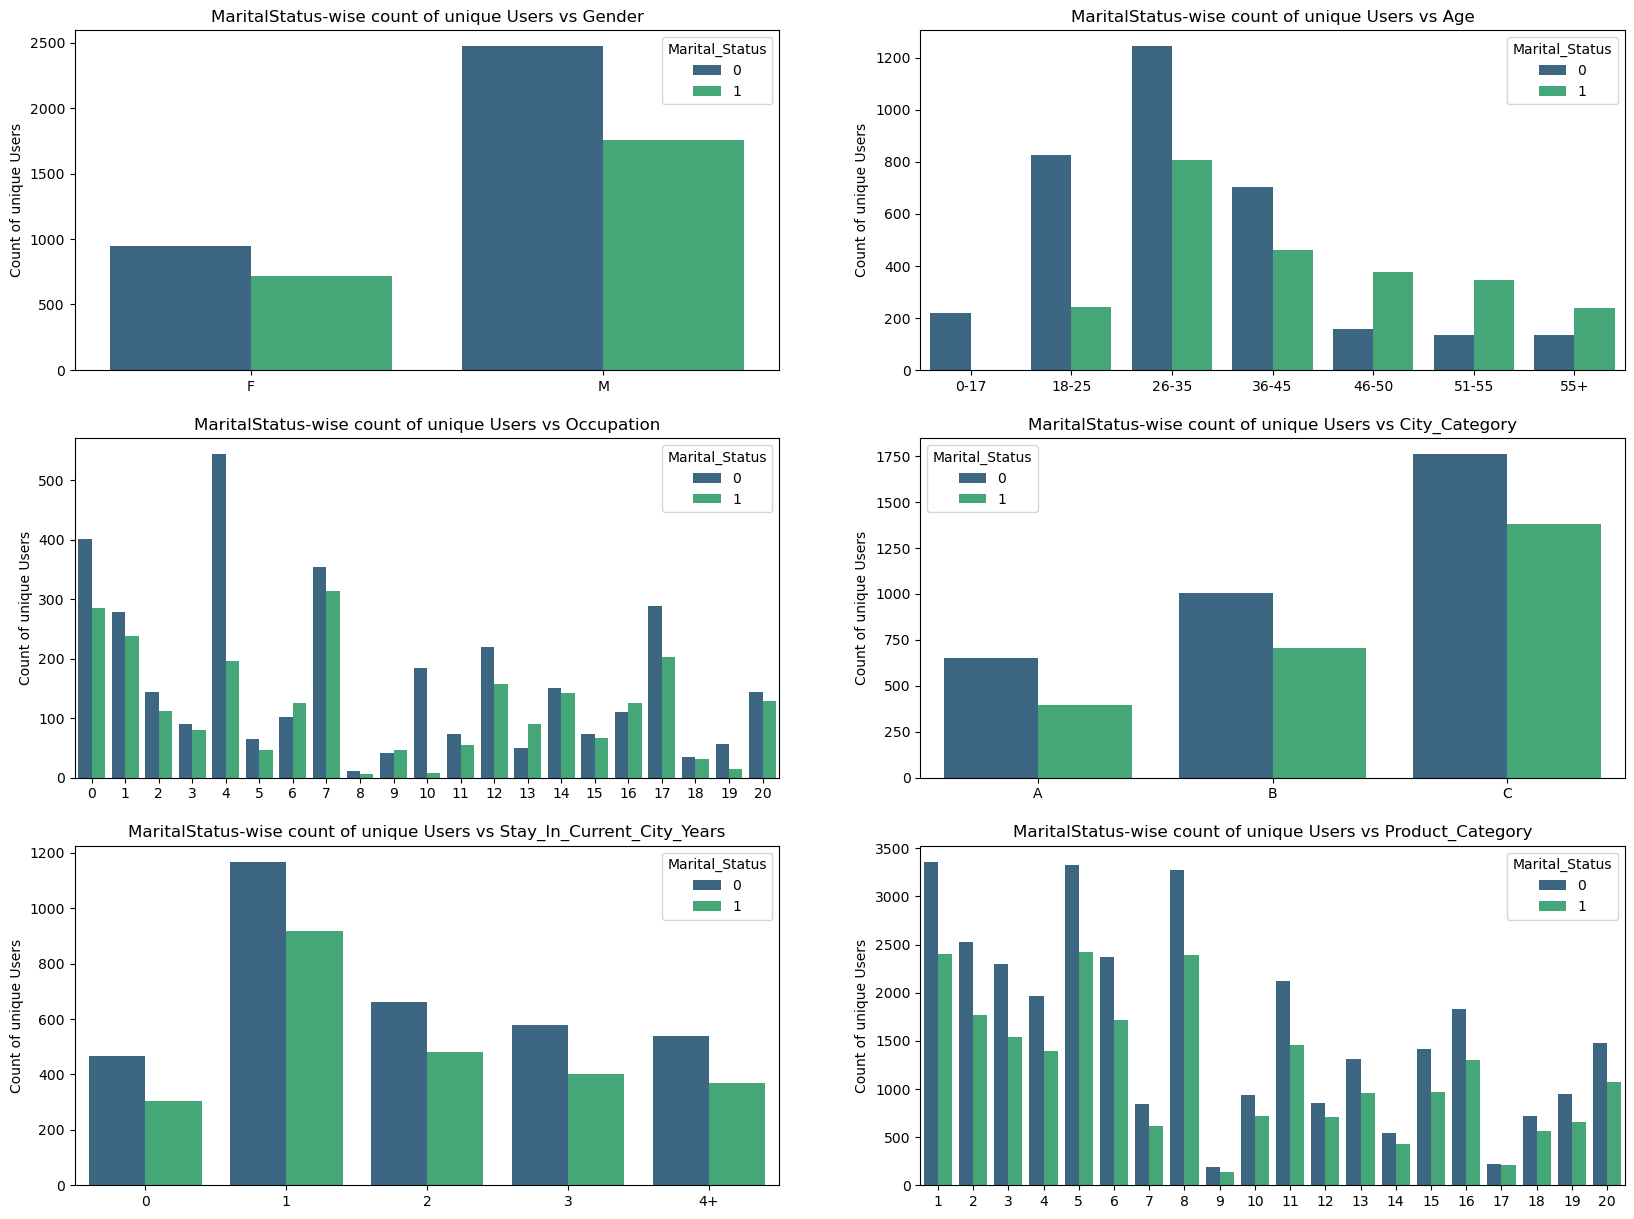

In [26]:
c = ['User_ID','Gender','Age','Occupation','City_Category','Stay_In_Current_City_Years','Product_Category']
plt.figure(figsize=(20,15))
for i in range(6):
    plt.subplot(3,2,i+1)
    plt.title(f'MaritalStatus-wise count of unique Users vs {c[i+1]}')
    sns.barplot(data=marital_status_wise_unique_User_ID_Counts.loc[(c[i+1])], y='User_ID', x='value', hue='Marital_Status', palette='viridis')
    plt.xlabel('')
    plt.ylabel('Count of unique Users')

How does gender affect the amount spent?

In [27]:
df.groupby('Gender')['Purchase'].describe()

C:\Users\Dell\AppData\Local\Temp\ipykernel_9084\1243678314.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Gender')['Purchase'].describe()


,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
F,135220.0,8671.049039,4679.058483,12.0,5429.0,7906.0,11064.0,21398.0
M,412171.0,9367.724355,5009.234088,12.0,5852.0,8089.0,12247.0,21399.0


In [28]:
df.sample(1000).groupby('Gender')['Purchase'].describe()

C:\Users\Dell\AppData\Local\Temp\ipykernel_9084\1361572616.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.sample(1000).groupby('Gender')['Purchase'].describe()


,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
F,256.0,8507.230469,4566.840813,14.0,5435.5,7894.0,10055.75,21309.0
M,744.0,9403.866935,5043.451097,12.0,5451.0,8116.5,12453.75,20937.0


In [29]:
F = df[df['Gender']=='F']

print('Mean Purchase Amount by Female Customers: ', round(F['Purchase'].mean(),1))
print('Standard Deviation of Purchase Amount by Female Customers: ', round(F['Purchase'].std(),1))

Mean Purchase Amount by Female Customers:  8671.0
Standard Deviation of Purchase Amount by Female Customers:  4679.1


In [30]:
M = df[df['Gender']=='M']

print('Mean Purchase Amount by Male Customers: ', round(M['Purchase'].mean(),1))
print('Standard Deviation of Purchase Amount by Male Customers: ', round(M['Purchase'].std(),1))

Mean Purchase Amount by Male Customers:  9367.7
Standard Deviation of Purchase Amount by Male Customers:  5009.2


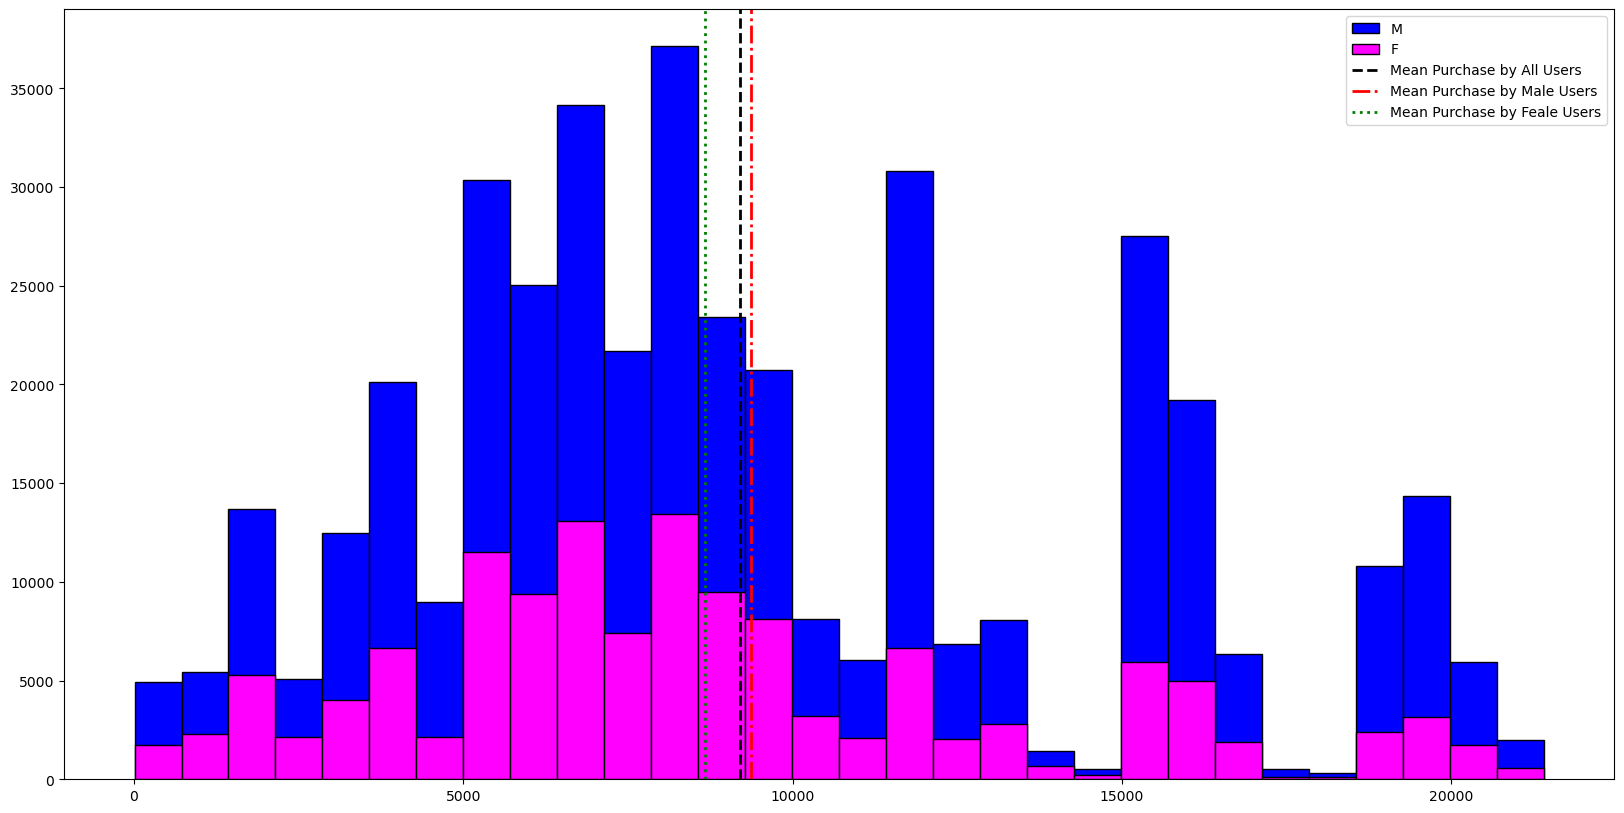

In [75]:
plt.figure(figsize=(20,10))
plt.hist(x=M['Purchase'], bins=30, label='M', edgecolor='black', color='blue')
plt.hist(x=F['Purchase'], bins=30, label='F', edgecolor='black', color='magenta')
plt.axvline(df['Purchase'].mean(), color='black', label='Mean Purchase by All Users', linewidth=2, linestyle='--')
plt.axvline(M['Purchase'].mean(), color='r', label='Mean Purchase by Male Users', linewidth=2, linestyle='-.')
plt.axvline(F['Purchase'].mean(), color='g', label='Mean Purchase by Feale Users', linewidth=2, linestyle=':')
plt.legend(loc='upper right')
plt.show()

<p style="page-break-after:always;"></p>

In [32]:
def bootstrap_gender_purchase():
    sample_sizes = [50,500,5000,50000]

    plt.figure(figsize=(20,30))
    
    bounds = {}

    for i,sample_size in enumerate(sample_sizes):
        F_sample_means = []
        M_sample_means = []

        bounds[sample_size] = {}

        for _ in range(10000):
            F_sample = F['Purchase'].sample(sample_size, replace=True)
            F_sample_mean = np.mean(F_sample)
            F_sample_means.append(F_sample_mean)
            M_sample = M['Purchase'].sample(sample_size, replace=True)
            M_sample_mean = np.mean(M_sample)
            M_sample_means.append(M_sample_mean)

        confidences = [90,95,99]
        linestyles = [':','-.','--']

        plt.subplot(4,1,i+1)
        plt.title(f'CLT for Gender, Sample Size = {sample_size}', fontsize=10)
        sns.kdeplot(data=F_sample_means, color='magenta', fill=True, label='Female (F)')
        sns.kdeplot(data=M_sample_means, color='blue', fill=True, label='Male (M)')

        for c,ls in zip(confidences,linestyles):
            F_lower = np.percentile(F_sample_means, (100-c)/2)
            F_upper = np.percentile(F_sample_means, (100+c)/2)
            M_lower = np.percentile(M_sample_means, (100-c)/2)
            M_upper = np.percentile(M_sample_means, (100+c)/2)

            bounds[sample_size][c] = {'F':(F_lower,F_upper), 'M':(M_lower,M_upper)}

            plt.axvline(F_lower, color='magenta', linewidth=2, linestyle=ls, label=f'F, CI={c}%')
            plt.axvline(F_upper, color='magenta', linewidth=2, linestyle=ls)
            plt.axvline(M_lower, color='blue', linewidth=2, linestyle=ls, label=f'M, CI={c}%')
            plt.axvline(M_upper, color='blue', linewidth=2, linestyle=ls)

        plt.legend()
    plt.tight_layout()
    plt.show()

    return bounds

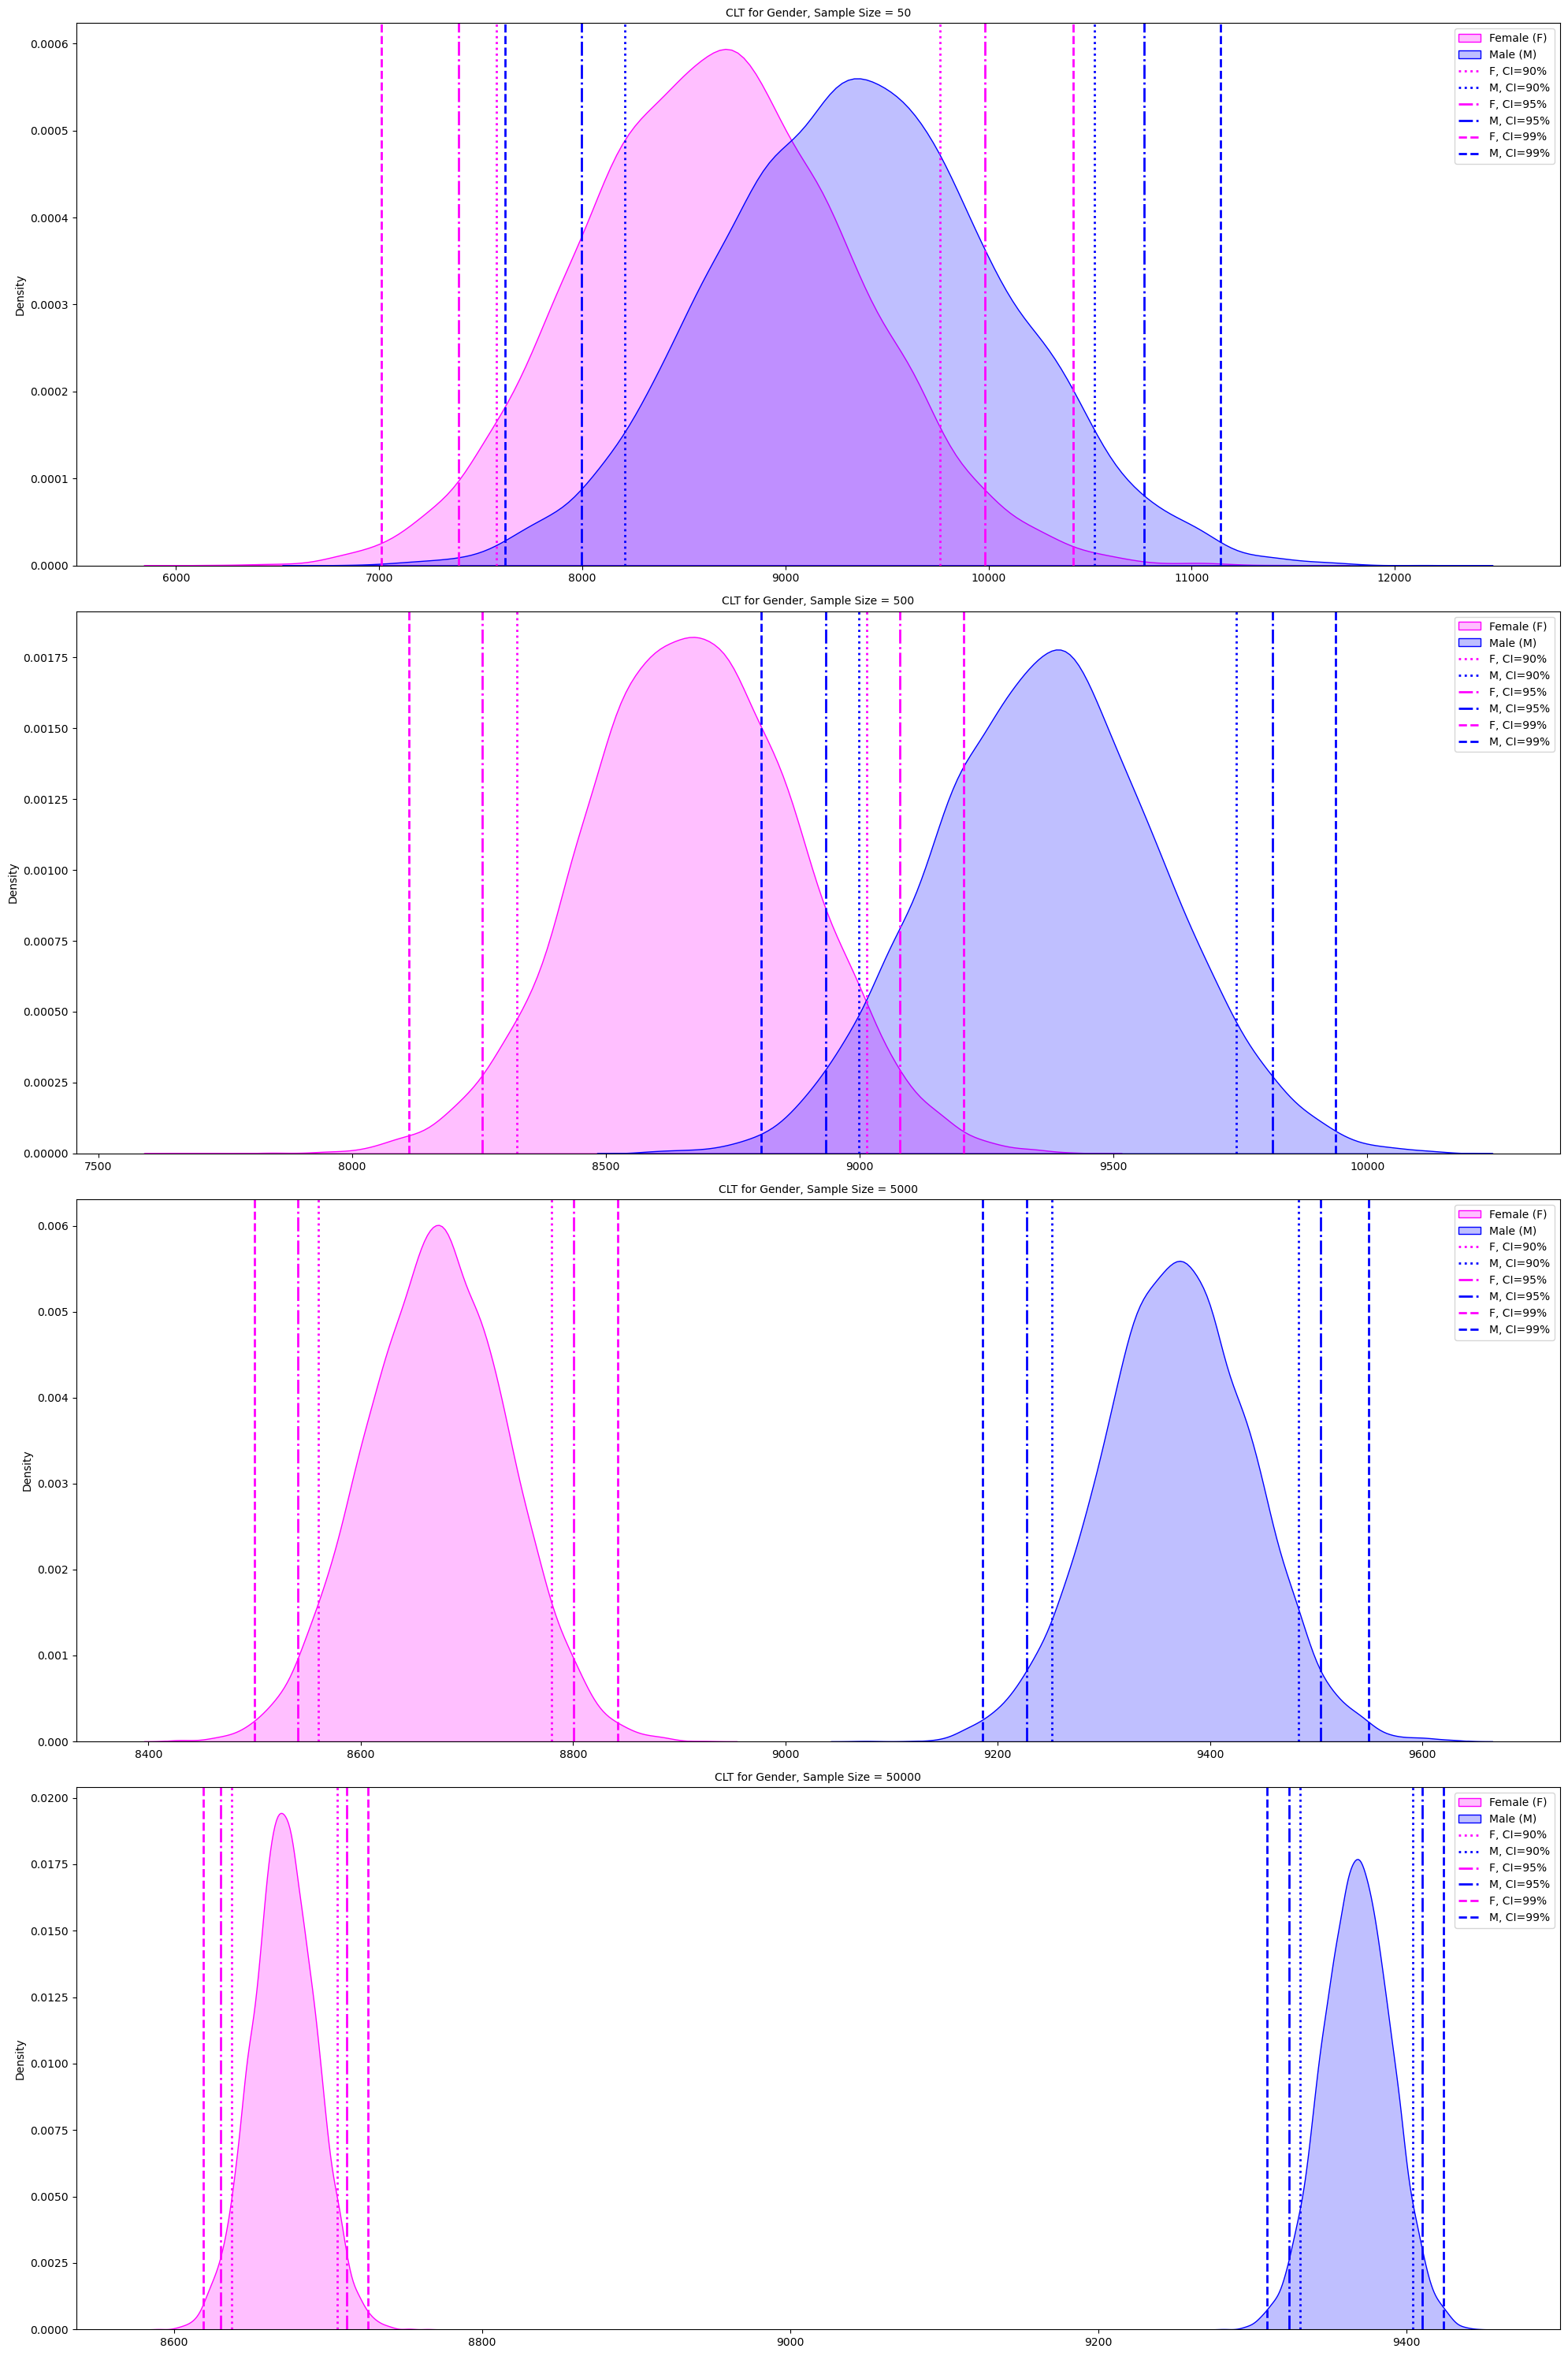

In [33]:
gender_intervals = bootstrap_gender_purchase()

<p style="page-break-after:always;"></p>

In [34]:
rows = []
for sample_size, conf_dict in gender_intervals.items():
    for confidence, gender_dict in conf_dict.items():
        for gender, (lower, upper) in gender_dict.items():
            rows.append({
                "Sample Size": sample_size,
                "Confidence Level (%)": confidence,
                "Gender": gender,
                "Lower Bound": round(lower),
                "Upper Bound": round(upper),
                "Range": round(upper-lower)
            })

df_gender = pd.DataFrame(rows)

def overlap(row):
    if (row.name)%2 == 1:
        overlap = max(0, df_gender.iloc[row.name-1]['Upper Bound'] - row['Lower Bound'])
        return overlap
    else:
        return '-'

df_gender['Overlap'] = df_gender.apply(overlap, axis=1)
df_gender.set_index(['Sample Size','Confidence Level (%)', 'Gender'], inplace=True)
df_gender

Lower Bound  Upper Bound  Range  \
Sample Size Confidence Level (%) Gender                                    
50          90                   F              7576         9762   2186   
                                 M              8209        10522   2313   
            95                   F              7389         9982   2593   
                                 M              7997        10766   2768   
            99                   F              7012        10418   3406   
                                 M              7619        11142   3523   
500         90                   F              8325         9014    688   
                                 M              8998         9742    744   
            95                   F              8256         9079    823   
                                 M              8933         9814    881   
            99                   F              8112         9205   1093   
                                 M              8806         9937   1131   
5000        90                   F              8560         8780    220   
                                 M              9251         9483    232   
            95                   F              8541         8801    260   
                                 M              9228         9504    277   
            99                   F              8500         8842    342   
                                 M              9186         9549    364   
50000       90                   F              8637         8706     68   
                                 M              9331         9404     73   
            95                   F              8630         8712     82   
                                 M              9324         9410     87   
            99                   F              8619         8726    107   
                                 M              9309         9424    115   

                                        Overlap  
Sample Size Confidence Level (%) Gender          
50          90                   F            -  
                                 M         1553  
            95                   F            -  
                                 M         1985  
            99                   F            -  
                                 M         2799  
500         90                   F            -  
                                 M           16  
            95                   F            -  
                                 M          146  
            99                   F            -  
                                 M          399  
5000        90                   F            -  
                                 M            0  
            95                   F            -  
                                 M            0  
            99                   F            -  
                                 M            0  
50000       90                   F            -  
                                 M            0  
            95                   F            -  
                                 M            0  
            99                   F            -  
                                 M            0

From the given table, we analyze whether the confidence intervals (CIs) for male and female average spends overlap:

- Sample Size 50: Overlapping at all confidence levels (90%, 95%, 99%).

- Sample Size 500: Overlapping at all confidence levels, though slightly at 99% CI.

- Sample Size 5000: No overlap at 90%, 95%, and 99% CI.

- Sample Size 50000: No overlap at 90%, 95%, and 99% CI.

<h4><b>Conclusion</b></h4>

For small sample sizes (50 & 500), the CIs overlap, suggesting that there might not be a significant difference in spending between genders.
For larger sample sizes (5000 & 50000), the CIs do not overlap, indicating a statistically significant difference in spending between male and female customers.

How Walmart Can Leverage This Insight?

<b>1. Gender-Specific Marketing Strategies:</b>

If males consistently spend more, Walmart can promote higher-end products or bulk deals targeted at them.
If female spending patterns vary differently, targeted discounts or personalized product recommendations may boost engagement.

<b>2. Assortment Planning & Store Layout:</b>

If men tend to spend more on specific categories (e.g., electronics), highlighting male-preferred products in key store locations can increase sales.
If female spending is distributed across different categories, Walmart can optimize product placements accordingly.

<b>3. Loyalty & Promotions:</b>

For segments where spending differences are significant, customized loyalty programs (e.g., cashback or targeted promotions) can maximize customer retention and spending.

<b>4. E-commerce Personalization:</b>

Walmart can use this data to personalize online shopping experiences, displaying relevant deals and product suggestions based on gender spending trends.

In [35]:
Unmarried = df[df['Marital_Status']==0]

print('Mean Purchase Amount by Unmarried Customers: ', round(Unmarried['Purchase'].mean(),1))
print('Standard Deviation of Purchase Amount by Unmarried Customers: ', round(Unmarried['Purchase'].std(),1))

Mean Purchase Amount by Unmarried Customers:  9201.6
Standard Deviation of Purchase Amount by Unmarried Customers:  4948.3


In [36]:
Married = df[df['Marital_Status']==1]

print('Mean Purchase Amount by Married Customers: ', round(Married['Purchase'].mean(),1))
print('Standard Deviation of Purchase Amount by Married Customers: ', round(Married['Purchase'].std(),1))

Mean Purchase Amount by Married Customers:  9187.0
Standard Deviation of Purchase Amount by Married Customers:  4925.2


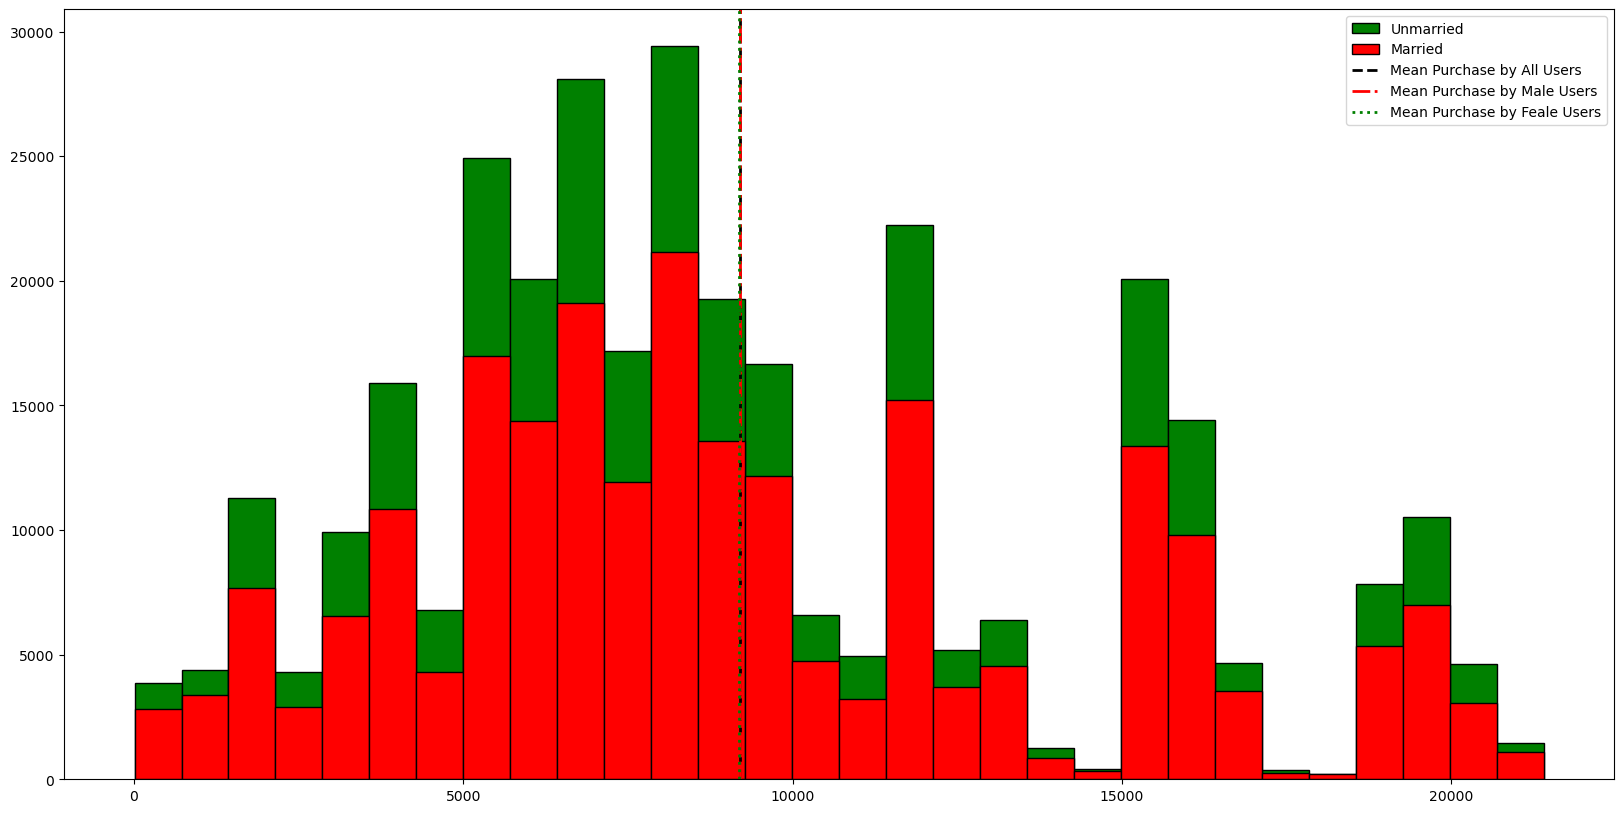

In [76]:
plt.figure(figsize=(20,10))
plt.hist(x=Unmarried['Purchase'], bins=30, label='Unmarried', edgecolor='black', color='green')
plt.hist(x=Married['Purchase'], bins=30, label='Married', edgecolor='black', color='red')
plt.axvline(df['Purchase'].mean(), color='black', label='Mean Purchase by All Users', linewidth=2, linestyle='--')
plt.axvline(Unmarried['Purchase'].mean(), color='r', label='Mean Purchase by Male Users', linewidth=2, linestyle='-.')
plt.axvline(Married['Purchase'].mean(), color='g', label='Mean Purchase by Feale Users', linewidth=2, linestyle=':')
plt.legend(loc='upper right')
plt.show()

In [38]:
def bootstrap_MaritalStatus_purchase():
    sample_sizes = [50,500,5000,50000]

    plt.figure(figsize=(20,30))
    
    bounds = {}

    for i,sample_size in enumerate(sample_sizes):
        Unmarried_sample_means = []
        Married_sample_means = []

        bounds[sample_size] = {}

        for _ in range(10000):
            Unmarried_sample = Unmarried['Purchase'].sample(sample_size, replace=True)
            Unmarried_sample_mean = np.mean(Unmarried_sample)
            Unmarried_sample_means.append(Unmarried_sample_mean)
            Married_sample = Married['Purchase'].sample(sample_size, replace=True)
            Married_sample_mean = np.mean(Married_sample)
            Married_sample_means.append(Married_sample_mean)

        confidences = [90,95,99]
        linestyles = [':','-.','--']

        plt.subplot(4,1,i+1)
        plt.title(f'CLT for Marital Status, Sample Size = {sample_size}', fontsize=10)
        sns.kdeplot(data=Unmarried_sample_means, color='green', fill=True, label='Unmarried')
        sns.kdeplot(data=Married_sample_means, color='red', fill=True, label='Married')

        for c,ls in zip(confidences,linestyles):
            Unmarried_lower = np.percentile(Unmarried_sample_means, (100-c)/2)
            Unmarried_upper = np.percentile(Unmarried_sample_means, (100+c)/2)
            Married_lower = np.percentile(Married_sample_means, (100-c)/2)
            Married_upper = np.percentile(Married_sample_means, (100+c)/2)

            bounds[sample_size][c] = {'Unmarried':(Unmarried_lower,Unmarried_upper), 'Married':(Married_lower,Married_upper)}

            plt.axvline(Unmarried_lower, color='green', linewidth=2, linestyle=ls, label=f'Unmarried, CI={c}%')
            plt.axvline(Unmarried_upper, color='green', linewidth=2, linestyle=ls)
            plt.axvline(Married_lower, color='red', linewidth=2, linestyle=ls, label=f'Married, CI={c}%')
            plt.axvline(Married_upper, color='red', linewidth=2, linestyle=ls)

        plt.legend()
    plt.tight_layout()
    plt.show()

    return bounds

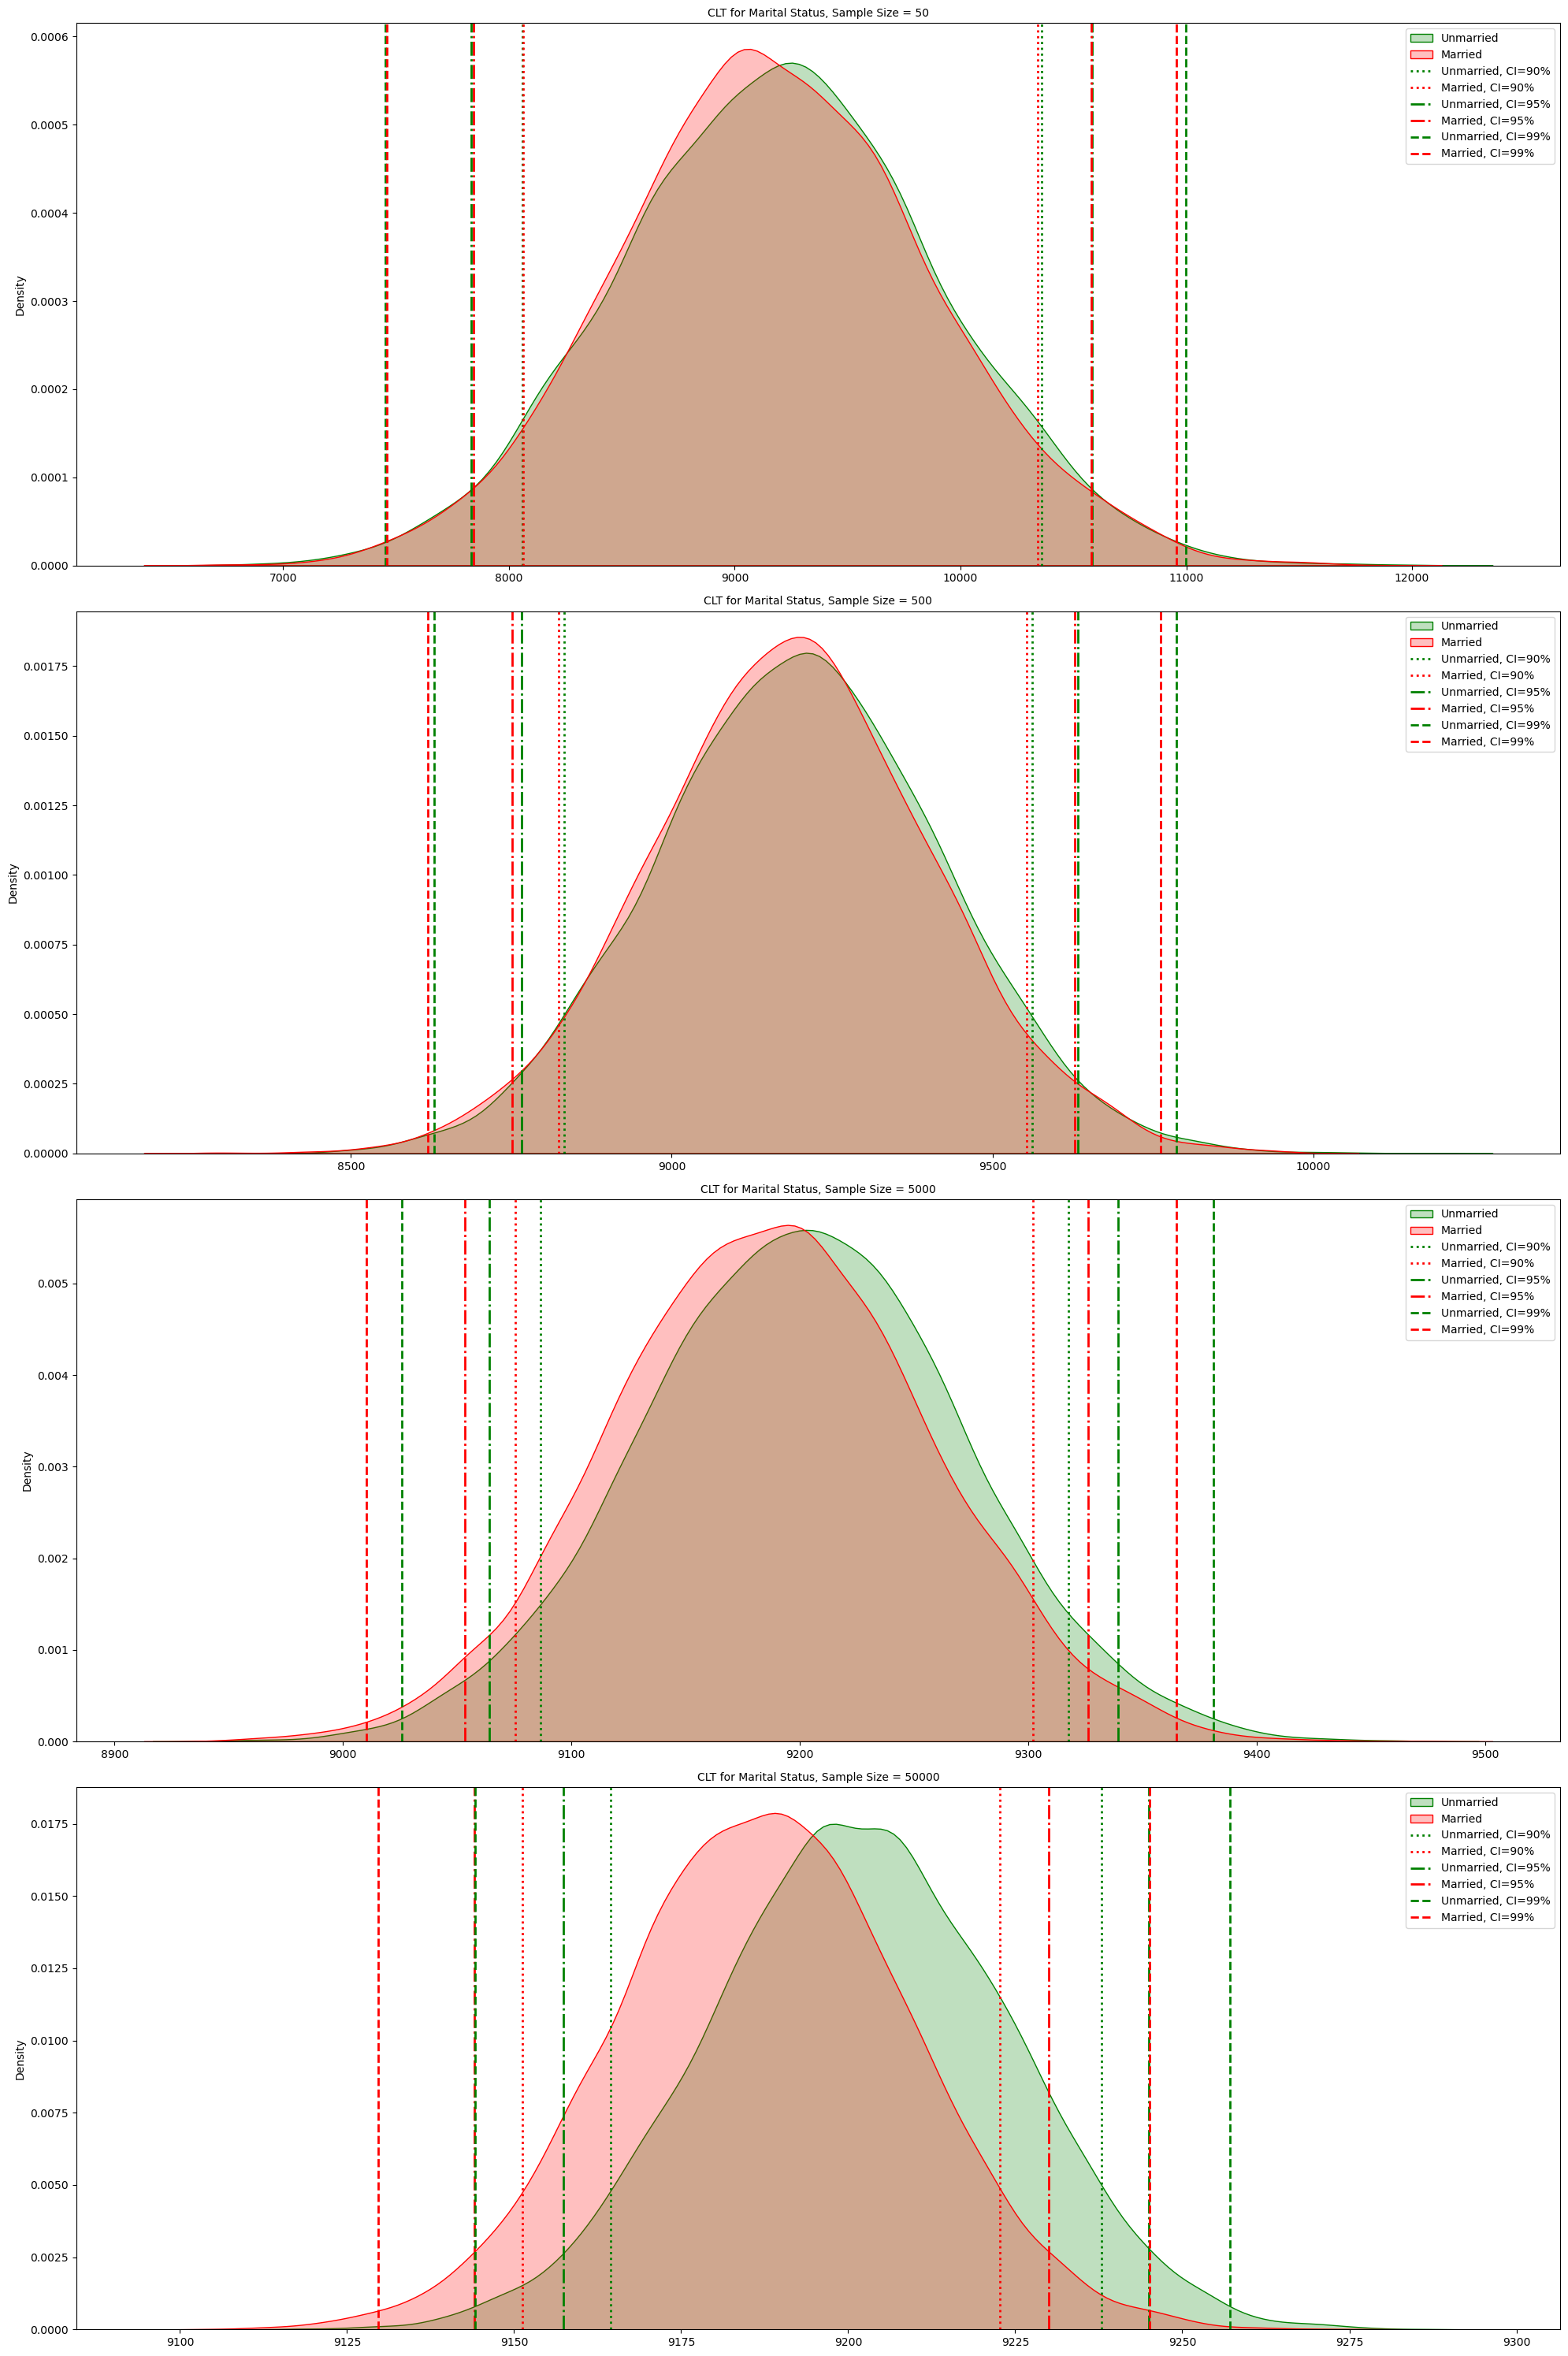

In [39]:
MaritalStatus_intervals = bootstrap_MaritalStatus_purchase()

In [40]:
rows = []
for sample_size, conf_dict in MaritalStatus_intervals.items():
    for confidence, MS_dict in conf_dict.items():
        for MS, (lower, upper) in MS_dict.items():
            rows.append({
                "Sample Size": sample_size,
                "Confidence Level (%)": confidence,
                "Marital Status": MS,
                "Lower Bound": round(lower),
                "Upper Bound": round(upper),
                "Range": round(upper-lower)
            })

df_MaritalStatus = pd.DataFrame(rows)

def overlap(row):
    if (row.name)%2 == 1:
        overlap = max(0, df_MaritalStatus.iloc[row.name-1]['Upper Bound'] - row['Lower Bound'])
        return overlap
    else:
        return '-'
    
df_MaritalStatus['Overlap'] = df_MaritalStatus.apply(overlap, axis=1)
df_MaritalStatus.set_index(['Sample Size','Confidence Level (%)', 'Marital Status'], inplace=True)
df_MaritalStatus

Lower Bound  Upper Bound  \
Sample Size Confidence Level (%) Marital Status                             
50          90                   Unmarried              8058        10361   
                                 Married                8062        10343   
            95                   Unmarried              7833        10582   
                                 Married                7845        10580   
            99                   Unmarried              7453        10998   
                                 Married                7459        10955   
500         90                   Unmarried              8833         9562   
                                 Married                8824         9553   
            95                   Unmarried              8766         9634   
                                 Married                8751         9628   
            99                   Unmarried              8629         9787   
                                 Married                8620         9762   
5000        90                   Unmarried              9086         9318   
                                 Married                9075         9302   
            95                   Unmarried              9064         9339   
                                 Married                9054         9326   
            99                   Unmarried              9026         9381   
                                 Married                9010         9365   
50000       90                   Unmarried              9164         9238   
                                 Married                9151         9223   
            95                   Unmarried              9157         9245   
                                 Married                9144         9230   
            99                   Unmarried              9144         9257   
                                 Married                9130         9245   

                                                 Range Overlap  
Sample Size Confidence Level (%) Marital Status                 
50          90                   Unmarried        2303       -  
                                 Married          2281    2299  
            95                   Unmarried        2749       -  
                                 Married          2736    2737  
            99                   Unmarried        3545       -  
                                 Married          3496    3539  
500         90                   Unmarried         729       -  
                                 Married           728     738  
            95                   Unmarried         868       -  
                                 Married           877     883  
            99                   Unmarried        1158       -  
                                 Married          1142    1167  
5000        90                   Unmarried         231       -  
                                 Married           227     243  
            95                   Unmarried         275       -  
                                 Married           273     285  
            99                   Unmarried         356       -  
                                 Married           355     371  
50000       90                   Unmarried          73       -  
                                 Married            71      87  
            95                   Unmarried          88       -  
                                 Married            86     101  
            99                   Unmarried         113       -  
                                 Married           115     127

We analyze the overlap of confidence intervals (CIs) for different sample sizes:

- Sample Size 50: Overlapping at all confidence levels (90%, 95%, 99%).

- Sample Size 500: Overlapping at all confidence levels.

- Sample Size 5000: Overlapping at all confidence levels.

- Sample Size 50000: Overlapping at all confidence levels.

<b><h4>Conclusion</b></h4>

Since the confidence intervals for Married and Unmarried customers consistently overlap across all sample sizes and confidence levels, there is no statistically significant difference in their spending behavior.

How Walmart Can Leverage This Insight?

Since spending behavior is similar between married and unmarried customers, Walmart should focus on universal strategies rather than segmenting based on marital status. Here are some possible actions:

<b>1. Broad-Based Promotions & Discounts:</b>

Since both groups spend similarly, Walmart can create general promotions rather than separate offers for married and unmarried customers.
Discounts, bundle deals, or seasonal sales should be targeted at broader demographics (e.g., income level, product preference) rather than marital status.

<b>2. Personalized Marketing Based on Other Factors:</b>

Instead of marital status, Walmart can focus on spending patterns based on age, product category, or location.
Personalized recommendations can be driven by individual purchasing behavior rather than assuming differences based on marital status.

<b>3. Enhancing Shopping Experience for Both Groups:</b>

Married customers may shop for family needs, while unmarried customers may have more discretionary spending. Analyzing cart composition and transaction data can help Walmart optimize in-store placement and product bundles.

<b>4. Targeted Advertising Based on Lifestyle Instead of Marital Status:</b>

Instead of targeting ads specifically to married or unmarried customers, Walmart should leverage data on lifestyle preferences, such as work-life balance, fitness habits, or home essentials.

<Axes: xlabel='Purchase', ylabel='Density'>

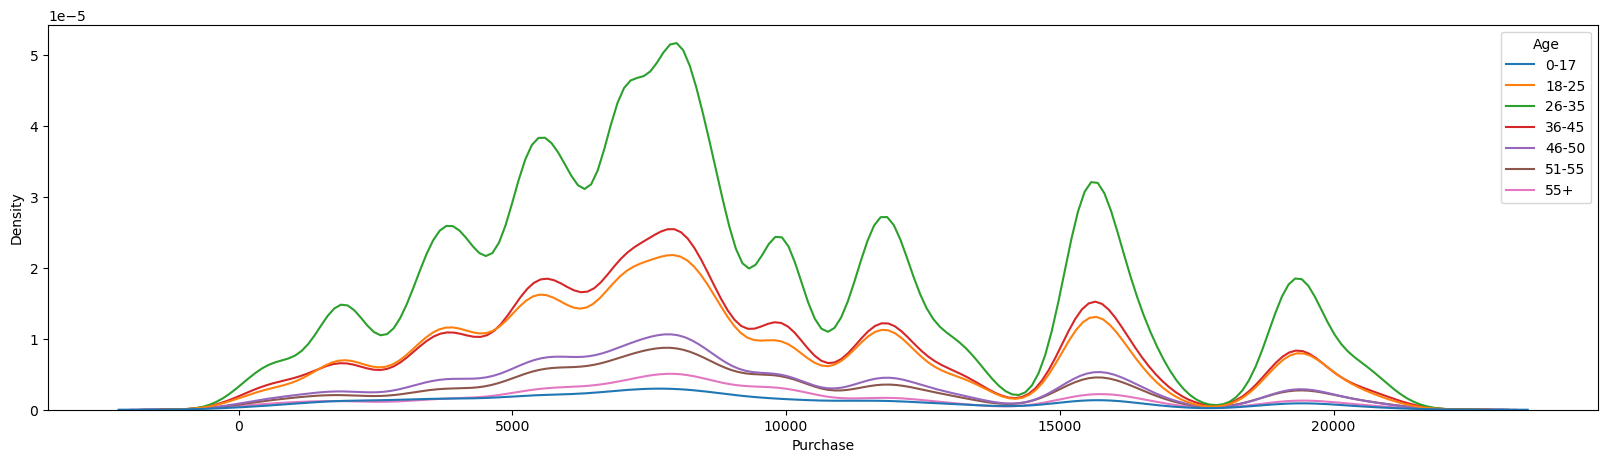

In [41]:
plt.figure(figsize=(20,5))
sns.kdeplot(data=df, x='Purchase', hue='Age', hue_order=sorted(df['Age'].unique()))

In [42]:
sorted(df['Age'].unique())

['0-17', '18-25', '26-35', '36-45', '46-50', '51-55', '55+']

In [48]:
def bootstrap_Age_purchase():
    sample_sizes = [50, 500, 5000, 50000]
    age_groups = sorted(df['Age'].unique())
    colors = sns.color_palette("husl", len(age_groups))
    plt.figure(figsize=(20, 40))
    bounds = {}
    
    for i, sample_size in enumerate(sample_sizes):
        age_sample_means = {age: [] for age in age_groups}
        bounds[sample_size] = {}
        
        for _ in range(10000):
            for age in age_groups:
                age_sample = df[df['Age'] == age]['Purchase'].sample(sample_size, replace=True)
                age_sample_means[age].append(np.mean(age_sample))
        
        confidences = [90, 95, 99]
        linestyles = [':', '-.', '--']
        
        plt.subplot(4, 1, i+1)
        plt.title(f'CLT for Age Groups, Sample Size = {sample_size}', fontsize=10)
        
        for age, color in zip(age_groups, colors):
            sns.kdeplot(data=age_sample_means[age], color=color, fill=True, label=f'Age: {age}')
        
        for c, ls in zip(confidences, linestyles):
            for age, color in zip(age_groups, colors):
                lower = np.percentile(age_sample_means[age], (100 - c) / 2)
                upper = np.percentile(age_sample_means[age], (100 + c) / 2)
                bounds[sample_size][c] = bounds[sample_size].get(c, {})
                bounds[sample_size][c][age] = (lower, upper)
                plt.axvline(lower, color=color, linewidth=2, linestyle=ls, label=f'Age {age}, CI={c}%')
                plt.axvline(upper, color=color, linewidth=2, linestyle=ls)
        
        plt.legend()
    
    plt.tight_layout()
    plt.show()
    return bounds


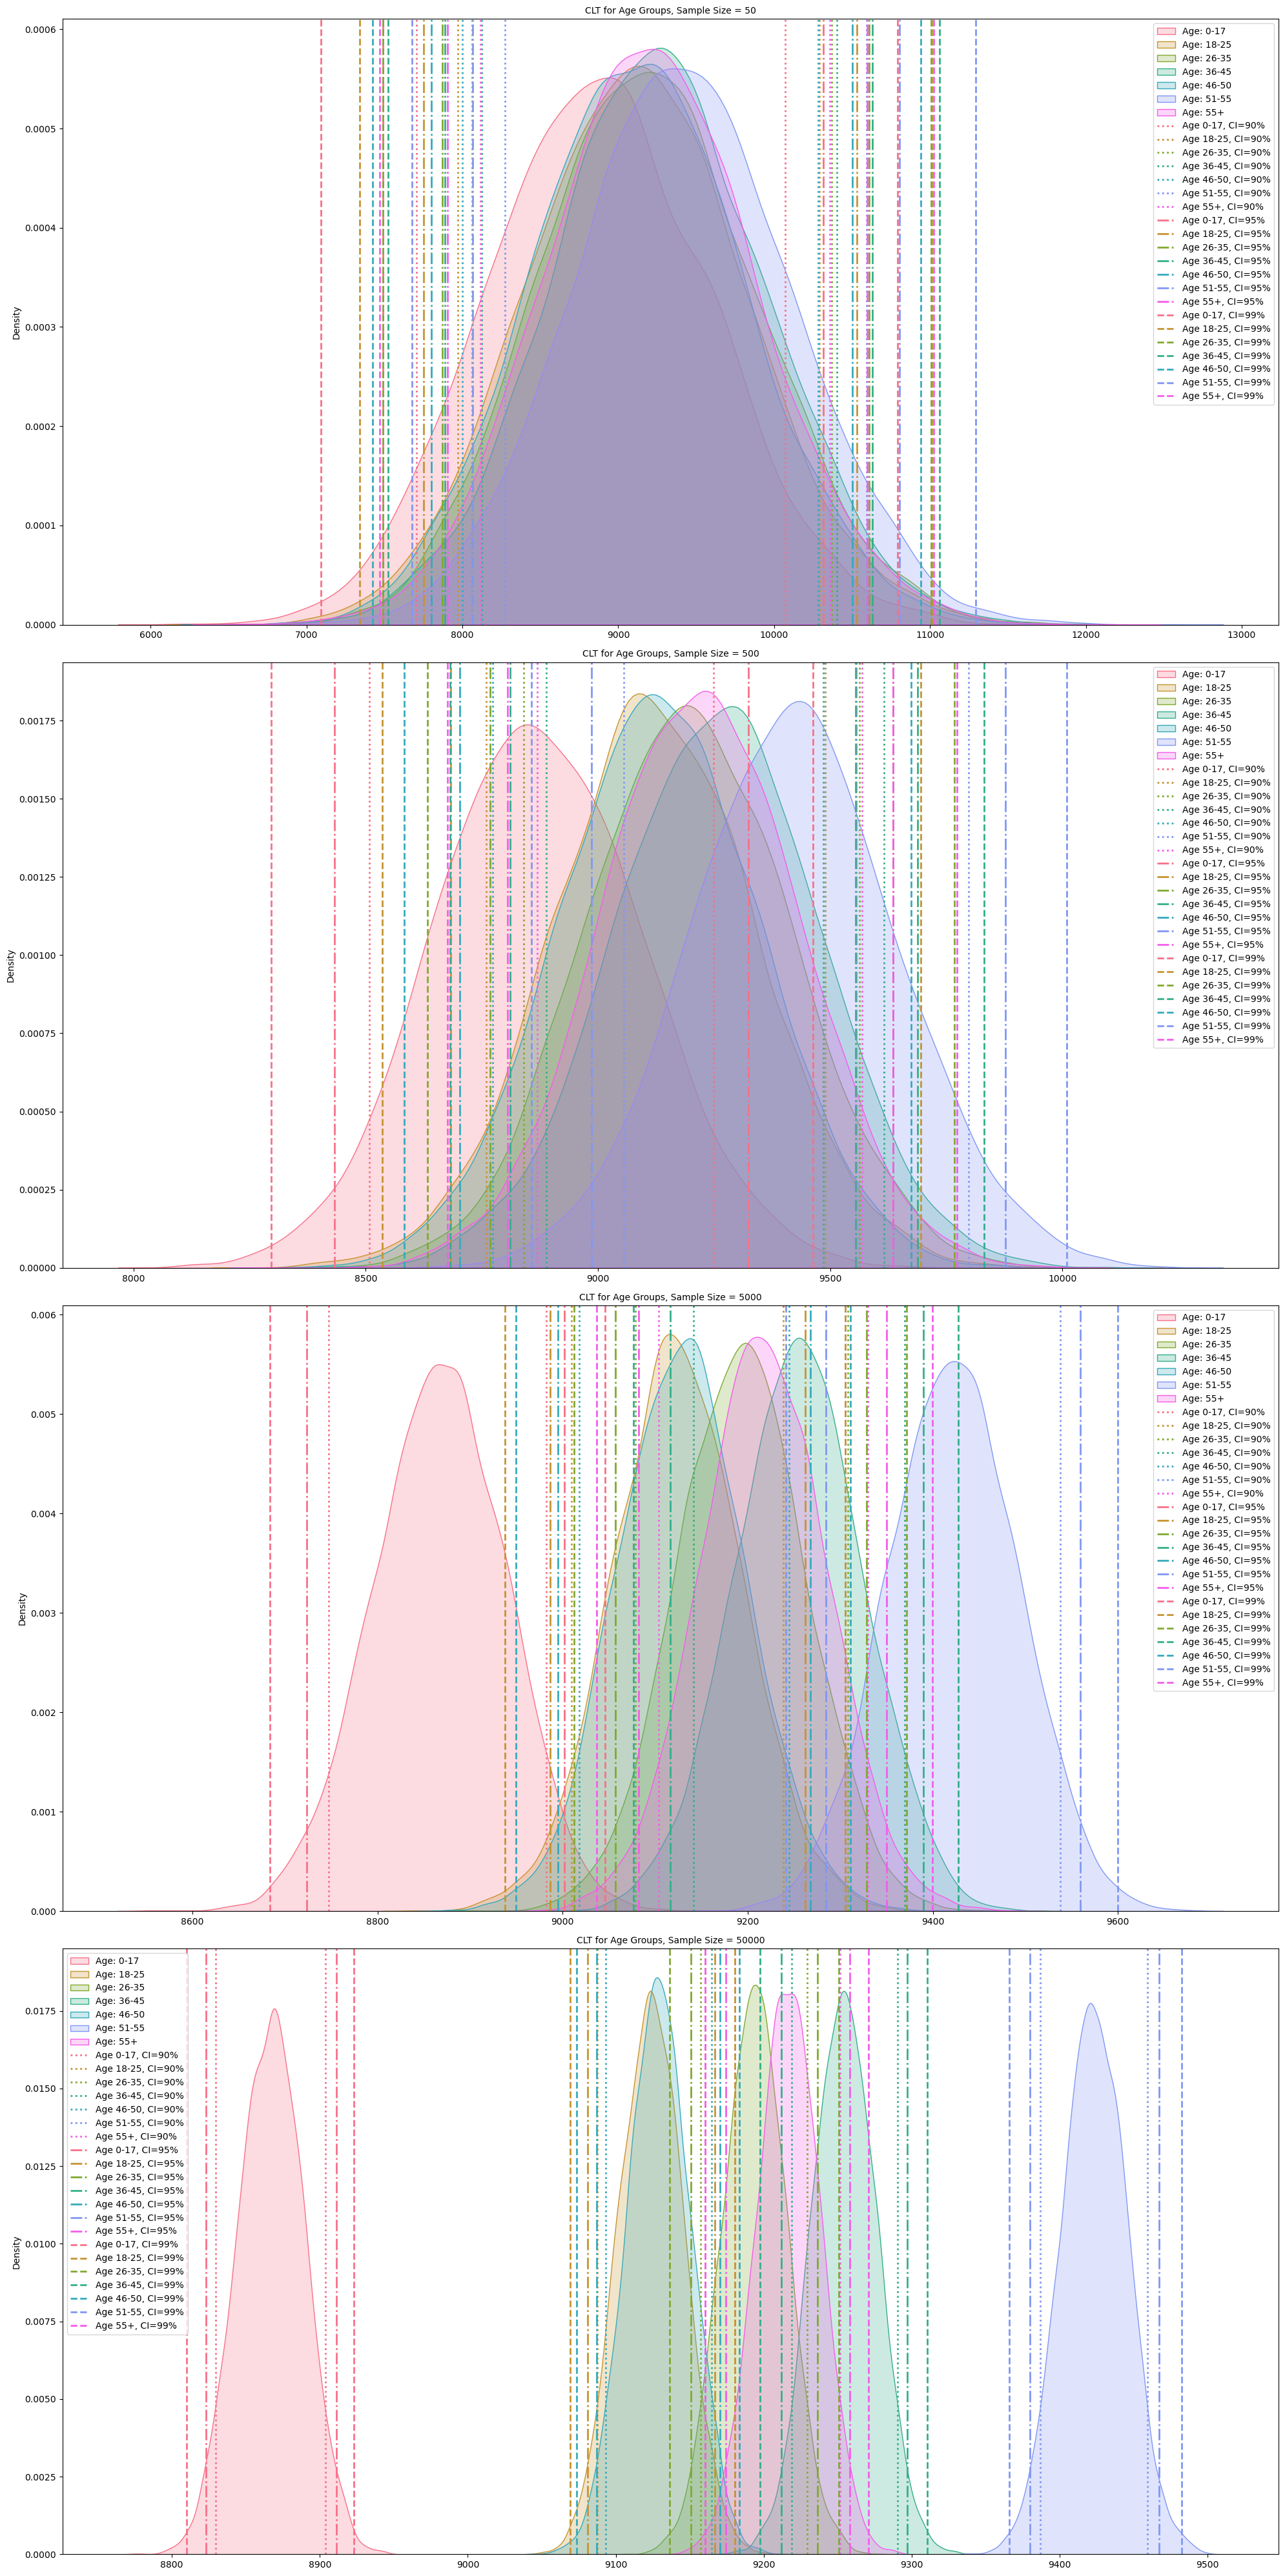

In [51]:
Age_intervals = bootstrap_Age_purchase()

In [61]:
rows = []
for sample_size, conf_dict in Age_intervals.items():
    for confidence, age_dict in conf_dict.items():
        for age_group, (lower, upper) in age_dict.items():
            rows.append({
                "Sample Size": sample_size,
                "Confidence Level (%)": confidence,
                "Age Group": age_group,
                "Lower Bound": round(lower),
                "Upper Bound": round(upper),
                "Range": round(upper-lower)
            })

df_Age = pd.DataFrame(rows)

df_Age.set_index(['Sample Size','Confidence Level (%)', 'Age Group'], inplace=True)

In [69]:
df_Age.loc[50]

Lower Bound  Upper Bound  Range
Confidence Level (%) Age Group                                 
90                   0-17              7708        10070   2363
                     18-25             7972        10289   2317
                     26-35             8063        10368   2305
                     36-45             8124        10401   2277
                     46-50             8001        10282   2281
                     51-55             8275        10593   2318
                     55+               8115        10355   2240
95                   0-17              7492        10317   2825
                     18-25             7753        10533   2780
                     26-35             7871        10609   2738
                     36-45             7887        10630   2743
                     46-50             7802        10500   2698
                     51-55             8067        10804   2737
                     55+               7906        10599   2693
99                   0-17              7092        10790   3698
                     18-25             7341        11013   3673
                     26-35             7489        11008   3519
                     36-45             7523        11061   3539
                     46-50             7422        10940   3518
                     51-55             7675        11291   3616
                     55+               7470        11025   3555

In [70]:
df_Age.loc[500]

Lower Bound  Upper Bound  Range
Confidence Level (%) Age Group                                 
90                   0-17              8508         9249    742
                     18-25             8759         9489    729
                     26-35             8840         9563    723
                     36-45             8889         9615    726
                     46-50             8774         9485    711
                     51-55             9055         9797    742
                     55+               8869         9569    700
95                   0-17              8433         9323    890
                     18-25             8683         9556    872
                     26-35             8768         9635    867
                     36-45             8812         9688    877
                     46-50             8702         9554    852
                     51-55             8985         9877    891
                     55+               8805         9635    830
99                   0-17              8297         9463   1166
                     18-25             8536         9695   1159
                     26-35             8633         9767   1134
                     36-45             8682         9831   1149
                     46-50             8584         9674   1091
                     51-55             8857        10009   1153
                     55+               8676         9773   1097

In [71]:
df_Age.loc[5000]

Lower Bound  Upper Bound  Range
Confidence Level (%) Age Group                                 
90                   0-17              8747         8982    235
                     18-25             9009         9239    229
                     26-35             9079         9308    230
                     36-45             9141         9370    229
                     46-50             9018         9245    227
                     51-55             9306         9538    232
                     55+               9104         9330    226
95                   0-17              8723         9002    278
                     18-25             8987         9262    276
                     26-35             9057         9328    272
                     36-45             9117         9390    273
                     46-50             8995         9268    273
                     51-55             9284         9559    275
                     55+               9082         9350    268
99                   0-17              8684         9046    362
                     18-25             8938         9305    367
                     26-35             9012         9372    359
                     36-45             9076         9428    351
                     46-50             8950         9311    361
                     51-55             9241         9600    359
                     55+               9037         9400    363

In [72]:
df_Age.loc[50000]

Lower Bound  Upper Bound  Range
Confidence Level (%) Age Group                                 
90                   0-17              8830         8904     74
                     18-25             9088         9160     73
                     26-35             9157         9229     72
                     36-45             9219         9290     72
                     46-50             9093         9165     72
                     51-55             9387         9459     72
                     55+               9181         9251     71
95                   0-17              8823         8911     88
                     18-25             9081         9167     86
                     26-35             9151         9236     86
                     36-45             9212         9297     85
                     46-50             9087         9171     84
                     51-55             9380         9467     87
                     55+               9174         9258     84
99                   0-17              8810         8923    113
                     18-25             9069         9180    111
                     26-35             9137         9251    114
                     36-45             9198         9310    113
                     46-50             9074         9183    110
                     51-55             9366         9483    116
                     55+               9160         9271    110

Let me analyze the confidence intervals for age-wise spending patterns.
From analyzing both the data and visualizations, here are the key findings about confidence intervals:

Age Group Spending Patterns:

- The 51-55 age group consistently shows the highest spending across all sample sizes, with notably higher upper and lower bounds
- The 0-17 age group generally shows the lowest spending levels
- The middle age groups (26-35, 36-45) show similar spending patterns with overlapping confidence intervals

Confidence Interval Analysis:

- At smaller sample sizes (n=50), there is significant overlap between all age groups, indicating less statistical certainty in spending differences.
- As sample size increases (n=500, n=5000, n=50000), the confidence intervals become narrower and more distinct.

At the largest sample size (n=50000), there are clear separations between some key groups:

- 51-55 age group has minimal overlap with other groups
- 0-17 age group is distinctly separated on the lower end
- Adult age groups (18-25, 26-35, 36-45) show some overlap with each other



<b>Recommendations:</b>

<b>1. Target Marketing and Merchandising:</b>

- Develop premium product lines and services targeting the 51-55 age group, as they consistently show higher spending capacity.
- Create value-oriented offerings for the 0-17 segment and their parents.
- Design unified marketing campaigns for the 26-45 age groups due to their similar spending patterns.


<b>2. Store Layout and Product Placement:</b>

- Position higher-margin items in areas frequently visited by the 51-55 age group.
- Create distinct shopping zones for different age segments based on their spending patterns.
- Optimize product mix based on age-specific spending capacities.

<b>3. Loyalty Programs:</b>

- Design tiered rewards programs that account for the different spending levels across age groups.
- Offer special incentives to the 51-55 age group to maintain their higher spending levels.
- Create targeted promotions for younger age groups to gradually increase their spending.

<b>4. Inventory Management:</b>

- Stock premium products in stores with higher concentrations of 51-55 age group customers.
- Adjust inventory mix based on the age demographics of each store's location.
- Implement dynamic pricing strategies based on age-specific spending patterns.